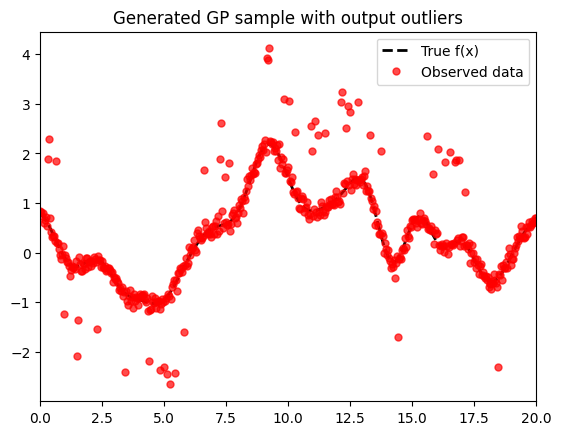

In [1]:
from typing import Optional, Any

import tensorflow as tf
import numpy as np
from check_shapes import check_shapes, inherit_check_shapes
from typing import Optional, Tuple, Type, Union, cast
import tensorflow_probability as tfp
import gpflow

from gpflow.base import InputData, MeanAndVariance, RegressionData, TensorData
from gpflow.kernels import Kernel
from gpflow.likelihoods import Gaussian
from gpflow.mean_functions import MeanFunction
from gpflow.models.model import GPModel
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
from gpflow.models.util import data_input_to_tensor


from gpflow.config import default_float, default_jitter
from gpflow.utilities import to_default_float
from gpflow import posteriors
from gpflow.utilities.ops import eye
import random

from numpy.lib.twodim_base import histogram2d
from tensorboard.plugins.histogram.summary import histogram
from tensorflow.python.ops.variables import trainable_variables

import w 

import tensorflow as tf
import numpy as np
import gpflow

import matplotlib.pyplot as plt
tf.keras.config.set_floatx('float64')
seed = 10

#set seed
np.random.seed(seed)
tf.random.set_seed(seed)

#create X
n_points = 500
sigma_n = 0.1
#percentage of points in x which are biased
percent_miss=0.1


#
lengthscale = 1
variance = 1

variance_out = 2

kernel=gpflow.kernels.SquaredExponential(lengthscales=lengthscale, variance=variance)

x = np.linspace(0, 20, n_points).reshape(n_points, 1)
f = np.random.multivariate_normal(mean=np.zeros(len(x)) ,cov=kernel(x, x)).reshape(n_points, 1)

i_obs = np.random.choice(
    np.arange(0, n_points, 1), int( n_points), replace=False)

y_obs = f[i_obs] + np.random.normal(scale=sigma_n, size=n_points).reshape(n_points, 1)
x_obs = x[i_obs]

arr1inds = x_obs[:,0].argsort()
x_obs = x_obs[arr1inds]
y_obs = y_obs[arr1inds]

i_mis = np.random.choice(
    np.arange(0, n_points, 1), int(percent_miss * n_points), replace=False)

upp=2
low=1
y_mis_pos = y_obs[i_mis[(y_obs[i_mis]>0)[:,0]]]  + np.random.uniform(low, upp, size=len(i_mis[(y_obs[i_mis]>0)[:,0]])).reshape(len(i_mis[(y_obs[i_mis]>0)[:,0]]),1)
y_mis_neg = y_obs[i_mis[(y_obs[i_mis]<=0)[:,0]]]  - np.random.uniform(low, upp, size=len(i_mis[(y_obs[i_mis]<=0)[:,0]])).reshape(len(i_mis[(y_obs[i_mis]<=0)[:,0]]),1)
y_obs[i_mis[(y_obs[i_mis]>0)[:,0]]] = y_mis_pos
y_obs[i_mis[(y_obs[i_mis]<=0)[:,0]]] = y_mis_neg
X=x
y=y_obs

plt.plot(x, f, color='black', ls='--', lw=2,label="True f(x)")
plt.plot(x_obs, y_obs, 'r.', ms=10, alpha=0.7,label="Observed data")
plt.xlim(x[0], x[-1])
plt.title("Generated GP sample with output outliers")
plt.legend()

In [2]:
from sklearn.model_selection import train_test_split
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import numpy as np
import w 


class GVI_RCGP_alpha(gpflow.models.BayesianModel):
    def __init__(self, X, y, Kernel, weightfunction,objective="GVI", Sigma_f_structure="c_f",
                 lambda_method="constant", inducing=[.0], alpha=0.5,
                 sigma=.25,test_size=0.15):
        super().__init__()
        self.X = X
        self.y = y

        # define if we are gonna optimize through the GVI or predictive.
        self.objective = objective
        self.alpha = gpflow.Parameter(alpha, trainable=False)
        if objective == "GVI":
            self.sigma = gpflow.Parameter(sigma, trainable=False)
        else:
            self.sigma = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        # define the weight
        self.weightfunction = weightfunction
        
        self.test_size=test_size
        # GP parameters
        self.kernel = Kernel
        self.inducing_variable = inducing

        # set structure for \Sigma_f
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        self.Sigma_f_structure = Sigma_f_structure

        # set lambda
        if lambda_method == "constant":
            self.lambda_i = tf.constant(1., dtype=tf.float64)
        elif lambda_method == "predictive" and objective == "predictive":
            self.lambda_i = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True,
                                             dtype=tf.float64)
        else:
            print("lambda method unknown")
        self.lambda_method = lambda_method

    tf.keras.backend.set_floatx('float64')

    # needed for the class
    def maximum_log_likelihood_objective(self):
        pass

    # update Sigma_f according to method.
    @tf.function
    def compute_sigma_f(self, X,J_w):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            Sigma_f = self.c_f * K @ tf.linalg.inv(
                    K + self.sigma**(2)/self.lambda_i* J_w) @J_w *self.sigma**(2)/self.lambda_i
        else:
            K = self.kernel(X, X)
            K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f

    @tf.function
    def train_step(self):
        if self.objective == "GVI":
            loss = self.GVI_step()
        else:
            loss = self.Pred_step()
        return loss
    
    def compute_weights(self,X,y):
        W_y=self.weightfunction.W(X,y)
        m_y=2*self.weightfunction.dy(X,y)
        J_w = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, -2)))
        J_w_inv = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, 2)))
        return m_y,J_w,J_w_inv


    def pred_log_prob(self, y, mu_f, sigma_y):
        # ensure 1-D vectors and float64 (gpflow/TensorFlow prefer float64 in many setups)
        y = tf.reshape(tf.cast(y, tf.float64), [-1])
        mu_f = tf.reshape(tf.cast(mu_f, tf.float64), [-1])
        sigma_y = tf.cast(sigma_y, tf.float64)

        # If sigma_y is a full covariance matrix, take diagonal (marginal variances)
        if sigma_y.shape.ndims == 2 and sigma_y.shape[0] == sigma_y.shape[1]:
            var = tf.linalg.diag_part(sigma_y)
        else:
            var = tf.reshape(sigma_y, [-1])


        # quadratic term (scalar)
        term_quad = 0.5 * tf.reduce_sum((y - mu_f) ** 2 / var)

        # log-determinant / normalizer term (scalar)
        term_log = 0.5 * tf.reduce_sum(tf.math.log(var))

        # optional extra term you had: make sure to treat self.sigma numerically
        try:
            inv_sigma2 = tf.math.reciprocal(tf.square(tf.cast(self.sigma, tf.float64)))
        except Exception:
            inv_sigma2 = tf.constant(0.0, dtype=tf.float64)

        term3 = 0.5 * inv_sigma2 * tf.reduce_sum(var + tf.square(tf.cast(self.sigma, tf.float64)))

        return term_quad + term_log + term3

    def GVI_step(self):
        #update weights
        m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        K, Sigma_f = self.compute_sigma_f(self.X,J_w)

        N = tf.cast(tf.shape(K)[0], tf.float64)
        eye = tf.eye(N, dtype=K.dtype)
        jitter = eye * 1e-6
        

        
        #compute matrixes
        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        
        #update mu
        q1 =self.alpha * Sigma_a@tf.linalg.inv(self.alpha * Sigma_a +self.sigma**(2) *J_w/self.lambda_i)
        mu_f = tf.matmul(q1,(self.y-m_y))

        # Log-determinants
        ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
        ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
        ld_K = tf.linalg.logdet(K + jitter)


        term1 = (tf.transpose(mu_f)@(self.sigma**(-2)*J_w_inv)@mu_f
               +tf.linalg.trace(Sigma_f@(self.sigma**(-2)*J_w_inv))
               -2*tf.transpose(mu_f)@(self.sigma**(-2)*J_w_inv)@(self.y-m_y))
        term2 = 0.5 * self.alpha * tf.transpose(mu_f) @ (Sigma_a_inv) @ (mu_f)
        term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
        loss = tf.squeeze(term1 + term2 + term3)
        
        #self.sigma.assign(tf.squeeze(tf.sqrt(tf.transpose(self.y-mu_f-m_y)@J_w_inv@(self.y-m_y-mu_f)/tf.reduce_sum(J_w_inv))))
        return loss

    def Pred_step(self):
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=self.test_size, random_state=0)
        
        
        #define weights and select with the same indexes
        m_y_train,J_w_train,J_w_inv_train=self.compute_weights(X_train,y_train)

        K, Sigma_f = self.compute_sigma_f(X_train,J_w_train)

        N = tf.cast(tf.shape(K)[0], tf.float64)

        eye = tf.eye(N, dtype=K.dtype)
        jitter = eye * 1e-6
        K_inv = tf.linalg.inv(K + jitter)

        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f

        q1 = self.alpha * Sigma_a @tf.linalg.inv(self.alpha * Sigma_a + self.sigma**(2)*J_w_train/self.lambda_i)
        mu_f = tf.matmul(q1, (y_train-m_y_train))

        K_star = self.kernel(X_test, X_train)
        K_star_star = self.kernel(X_test, X_test)

        mu_p = K_star @ K_inv @ mu_f
        A = K_star_star - K_star @ K_inv @ tf.transpose(K_star) \
            + K_star @ K_inv @ Sigma_f @ tf.transpose(K_star @ K_inv)

        # use diagonal of covariance directly
        sigma_p = tf.linalg.diag_part(A)  # no inverse here

        
        var_y = sigma_p + tf.cast(self.sigma ** 2, tf.float64)
        term1 = self.pred_log_prob(y_test, mu_p, var_y)

        return term1



    def predict_ins(self):
        m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        K, Sigma_f = self.compute_sigma_f(self.X,J_w)

        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f
        q1 = self.alpha * Sigma_a@tf.linalg.inv(self.alpha * Sigma_a + self.sigma**(2)*J_w/self.lambda_i)
        mu_f = tf.matmul(q1, (self.y-m_y))
        self.mu_f = mu_f
        self.Sigma_f = Sigma_f
        self.K = K

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)

    def internal_opt(self, n_it=10):
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        
        for i in range(n_it):
            with tf.GradientTape(persistent=True) as tape:
                loss = self.train_step()
            grads = tape.gradient(loss, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)

    def predict_out(self, X):
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)




In [3]:
N = X.shape[0]
Z = X[np.random.choice(N, 20, replace=False), :]
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
inducing_variable = gpflow.Parameter(Z, trainable=False)
model = GVI_RCGP_alpha(X, y, kernel)
model.internal_opt()
model.predict_ins()
tf.reduce_mean((model.mu_f - f) ** 2)

TypeError: GVI_RCGP_alpha.__init__() missing 1 required positional argument: 'weightfunction'

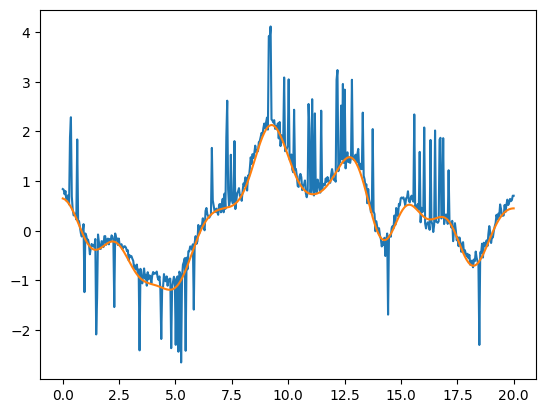

In [4]:
plt.plot(X, y)
plt.plot(X, model.mu_f)

In [5]:
tf.reduce_mean((f-model.mu_f)**2)

<tf.Tensor: shape=(), dtype=float64, numpy=0.010156008550282617>

In [5]:
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow

tfpk = tfp.math.psd_kernels

class GVI_SRCGPR_alpha(gpflow.models.BayesianModel):
    def __init__(self, X, y, inducing,Kernel,  weightfunction,sigma=1., structure="Diag", alpha=0.5,
                 test_size=0.1, objective="GVI"):
        super().__init__()
        self.X = tf.cast(X, tf.float64)
        self.y = tf.cast(y, tf.float64)
        self.inducing_variable = tf.cast(inducing, tf.float64)
        self.N_u = inducing.shape[0]
        self.objective = objective

        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.test_size = test_size

        #
        self.kernel=Kernel
        # define the weight
        self.weightfunction = weightfunction

        # Other GP parameters
        self.lambda_i = 1.
        self.sigma = tf.Variable(sigma, dtype=tf.float64, trainable=False)


    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)


    
    def compute_weights(self,X,y):
        W_y=self.weightfunction.W(X,y)
        m_y=2*self.weightfunction.dy(X,y)
        J_w = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, -2)))
        J_w_inv = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, 2)))
        return m_y,J_w,J_w_inv
    
    
    @tf.function
    def train_step(self):
        return self.GVI_step()

    def GVI_step(self):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        N = tf.cast(tf.shape(self.X)[0], tf.float64)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)

        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        m_y, J_w, J_w_inv = self.compute_weights(self.X, self.y)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ J_w @ K_fu @ K_uu_inv) *self.sigma ** (-2)* self.lambda_i
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, J_w @ (self.y-m_y)) * self.sigma ** (-2) * self.lambda_i
        mu_u = tf.matmul(q1, q2)

        
        T1 = K_uu_inv @ (K_uf @ J_w @ K_fu)
        T2 = T1 @ (K_uu_inv @ Sigma_u)
        
        #kernel diagonal, to specify if we change the kernel
        K = self.kernel(self.X, self.X)

        term1 = 0.5 * tf.reduce_sum(tf.transpose(mu_u)@K_uu_inv@K_uf@J_w_inv@K_fu @ K_uu_inv @ mu_u) * (self.sigma ** -2) * self.lambda_i
        term1 -= tf.reduce_sum(tf.transpose(mu_u)@K_uu_inv@K_uf@J_w_inv@(self.y-m_y)) * (self.sigma ** -2) * self.lambda_i
        term1 += 0.5 * self.lambda_i * (N * tf.reduce_sum(tf.linalg.diag_part(K)) - tf.linalg.trace(T1) + tf.linalg.trace(T2)) * self.lambda_i
        term1 += N * tf.math.log(self.sigma)

        term2 = 0.5 * self.alpha * tf.reduce_sum(mu_u * (Sigma_a_inv @ mu_u))

        ld_K = tf.linalg.logdet(K_uu + jitter)
        ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
        ld_Sig_u = tf.linalg.logdet(Sigma_u + jitter)
        term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_u - self.alpha * ld_K)

        return tf.squeeze(term1 + term2 + term3)

    def predict_ins(self):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        m_y, J_w, _ = self.compute_weights(self.X, self.y)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ J_w @ K_fu @ K_uu_inv) / self.sigma ** 2 * self.lambda_i
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, J_w @ (self.y - self.sigma**2*m_y)) / (self.sigma ** 2) * self.lambda_i

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u

    def predict_out(self, Xnew):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)

    def internal_opt(self, n_it=10):
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        for i in range(n_it):
            with tf.GradientTape(persistent=True) as tape:
                loss = self.train_step()
            grads = tape.gradient(loss, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)
    def maximum_log_likelihood_objective(self):
        pass


In [6]:
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow

tfpk = tfp.math.psd_kernels

class GVI_SRCGPR_2_alpha(gpflow.models.BayesianModel):
    def __init__(self, X, y, inducing,Kernel,  weightfunction,sigma=1., structure="Diag", alpha=0.5,
                 test_size=0.1, objective="GVI"):
        super().__init__()
        self.X = tf.cast(X, tf.float64)
        self.y = tf.cast(y, tf.float64)
        self.inducing_variable = tf.cast(inducing, tf.float64)
        self.N_u = inducing.shape[0]
        self.objective = objective

        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.test_size = test_size

        #
        self.kernel=Kernel
        # define the weight
        self.weightfunction = weightfunction

        # Other GP parameters
        self.lambda_i = 1.
        self.sigma = tf.Variable(sigma, dtype=tf.float64, trainable=False)


    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)


    
    def compute_weights(self,X,y):
        W_y=self.weightfunction.W(X,y)
        m_y=2*self.weightfunction.dy(X,y)
        J_w = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, -2)))
        J_w_inv = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, 2)))
        return m_y,J_w,J_w_inv
    
    
    @tf.function
    def train_step(self):
        return self.GVI_step()

    def GVI_step(self):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        N = tf.cast(tf.shape(self.X)[0], tf.float64)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)

        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        m_y, J_w, J_w_inv = self.compute_weights(self.X, self.y)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ J_w @ K_fu @ K_uu_inv) *self.sigma ** (-2)* self.lambda_i
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, J_w @ (self.y-m_y)) * self.sigma ** (-2) * self.lambda_i
        mu_u = tf.matmul(q1, q2)

        
        T1 = K_uu_inv @ (K_uf @ J_w @ K_fu)
        T2 = T1 @ (K_uu_inv @ Sigma_u)
        
        #kernel diagonal, to specify if we change the kernel
        K = self.kernel(self.X, self.X)

        term1 = 0.5 * tf.reduce_sum(tf.transpose(mu_u)@K_uu_inv@K_uf@J_w_inv@K_fu @ K_uu_inv @ mu_u) * (self.sigma ** -2) * self.lambda_i
        term1 -= tf.reduce_sum(tf.transpose(mu_u)@K_uu_inv@K_uf@J_w_inv@(self.y-m_y)) * (self.sigma ** -2) * self.lambda_i
        term1 += 0.5 * self.lambda_i * (N * tf.reduce_sum(tf.linalg.diag_part(K)) - tf.linalg.trace(T1) + tf.linalg.trace(T2)) * self.lambda_i
        term1 += N * tf.math.log(self.sigma)

        term2 = 0.5 * self.alpha * tf.reduce_sum(mu_u * (Sigma_a_inv @ mu_u))

        ld_K = tf.linalg.logdet(K_uu + jitter)
        ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
        ld_Sig_u = tf.linalg.logdet(Sigma_u + jitter)
        term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_u - self.alpha * ld_K)

        return tf.squeeze(term1 + term2 + term3)

    def predict_ins(self):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        m_y, J_w, _ = self.compute_weights(self.X, self.y)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ J_w @ K_fu @ K_uu_inv) / self.sigma ** 2 * self.lambda_i
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, J_w @ (self.y - self.sigma**2*m_y)) / (self.sigma ** 2) * self.lambda_i

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u

    def predict_out(self, Xnew):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)

    def internal_opt(self, n_it=10):
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        for i in range(n_it):
            with tf.GradientTape(persistent=True) as tape:
                loss = self.train_step()
            grads = tape.gradient(loss, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)
    def maximum_log_likelihood_objective(self):
        pass


In [7]:
N=X.shape[0]
Z =X[np.random.choice(N, 50, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
kernel = gpflow.kernels.SquaredExponential()
model = GVI_SRCGPR_alpha(X,y,inducing_variable,kernel)
model.internal_opt()
model.predict_ins()
f,s=model.predict_out(X)
mu=f


TypeError: GVI_SRCGPR_alpha.__init__() missing 1 required positional argument: 'weightfunction'

In [8]:
plt.plot(X,mu)
plt.plot(X,y)

NameError: name 'mu' is not defined

In [9]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_T(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,Kernel,Sigma_f_structure="c_f", alpha=0.5,nu=2):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)

        # GP parameters
        self.kernel = Kernel
        self.inducing_variable = tf.cast(inducing, tf.float64)
        self.sigma=gpflow.Parameter(1.,trainable=False)
        
        self.nu=tf.constant(nu,dtype=tf.float64)
        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
        # set structure for \Sigma_f
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        self.Sigma_f_structure = Sigma_f_structure

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    @tf.function
    def update_mu_f(self, Sigma_a_inv,Lambda_inv):
        q1 = tf.linalg.inv(self.alpha * Sigma_a_inv + Lambda_inv)
        q2 = tf.matmul(Lambda_inv , self.y)
        return tf.matmul(q1, q2)
    
    def maximum_log_likelihood_objective(self):
        pass
        
        
    # update Sigma_f according to method.
    @tf.function
    def compute_sigma_f(self, X,Lambda_inv):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            Sigma_f = self.c_f * K @ tf.linalg.inv(
                    K + Lambda_inv) @Lambda_inv * self.sigma ** 2 
        else:
            K = self.kernel(X, X)
            K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f
    
    
    
    def predict_in(self):   
        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        K, Sigma_f = self.compute_sigma_f(self.X,Lambda_inv)
        
        N = tf.cast(tf.shape(K)[0],tf.float64)
        print(N.dtype)
        identity = tf.eye(N, dtype=K.dtype)
        jitter = identity * 1e-6
        K_j = K + jitter


        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        self.mu_f = self.update_mu_f(Sigma_a_inv,Lambda_inv)
        self.Sigma_f=Sigma_f
        
    def predict_out(self,X):        
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            K, Sigma_f = self.compute_sigma_f(self.X,Lambda_inv)
            
            N = tf.cast(tf.shape(K)[0],tf.float64)
            print(N.dtype)
            identity = tf.eye(N, dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter


            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            mu_f = self.update_mu_f(Sigma_a_inv,Lambda_inv)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = 0.5 *  tf.transpose(mu_f) @ (Lambda_inv+Sigma_a_inv) @ mu_f
            term2 = -  tf.transpose(mu_f) @Lambda_inv @ (self.y)
            term4 = 0.5 * self.sigma**(-2) * tf.linalg.trace(Lambda_inv @ Sigma_f)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - mu_f
        num=self.nu+1
        denom=self.nu*self.sigma**2+tf.squeeze(residual)**2+tf.linalg.diag_part(Sigma_f)
        self.lambda_inv.assign(tf.squeeze((num / denom)))
         
        return loss
    

    def train(self, max_steps=500, tolerance=0.05, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
model = GVI_GP_T(X, y,inducing_variable,kernel)
model.train()

<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: -28.440444910464407
Step: 1 Loss: -74.5782658728451
Step: 2 Loss: -71.15136923118001
Step: 3 Loss: -70.98109198423427
Step: 4 Loss: -71.06873654377515
Step: 5 Loss: -71.19056268851571
Step: 6 Loss: -71.31584074783757
Step: 7 Loss: -71.44009366540894
Step: 8 Loss: -71.56238085532871
Step: 9 Loss: -71.68235194482611
Step: 10 Loss: -71.7998028354485
Step: 11 Loss: -71.91459406508434
Step: 12 Loss: -72.02662555760094
Step: 13 Loss: -72.13582601985308
Step: 14 Loss: -72.24214671550689
Step: 15 Loss: -72.34555716535226
Step: 16 Loss: -72.44604315752179
Step: 17 Loss: -72.54360414173226
Step: 18 Loss: -72.63825233480236
Step: 19 Loss: -72.73001088063293
Step: 20 Loss: -72.81891251373295
Step: 21 Loss: -72.90499976572363
Step: 22 Loss: -72.98832247388555
Step: 23 Loss: -73.0689381683544
Step: 24 Loss: -73.14691060391056
Step: 25 Loss: -73.22230795371541
Step: 26 Loss: -73.29520377732138
Step: 27 Loss: -73.3656741573827
Step: 28 Loss: -73.4337

<dtype: 'float64'>


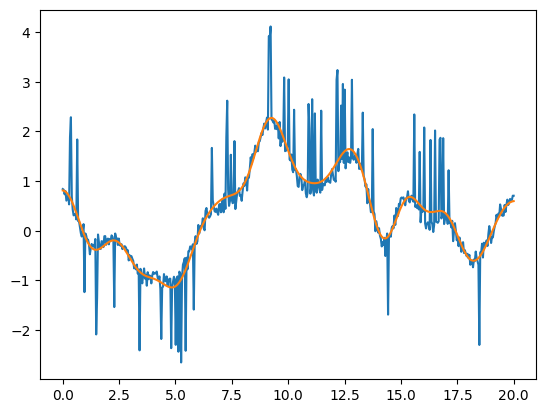

In [10]:
model.predict_in()
plt.plot(X,y)
plt.plot(X,model.mu_f)

In [11]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_WELSCH(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,Kernel,Sigma_f_structure="inducing", alpha=0.5,c_prop=2.5):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.c=tf.Variable(tf.sqrt(c_prop*tf.reduce_mean(self.y**2)),dtype=tf.float64,trainable=False)
        self.c_prop=c_prop
        
        # set structure for \Sigma_f
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
            
        self.Sigma_f_structure = Sigma_f_structure
        self.kernel=Kernel
        
        self.inducing_variable = inducing
        self.mu_f = tf.Variable(tf.ones(self.y.shape, dtype=tf.float64),trainable=False)
        #self.mu_f=tf.reshape(self.mu_f, [-1, 1])

        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
        
    @tf.function
    def compute_sigma_f(self, X):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            eye=tf.eye(tf.shape(K)[0], dtype=K.dtype)

            Sigma_f =  K + self.c_f *eye
        else:
            K = self.kernel(X, X)
            K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K, Sigma_f = self.compute_sigma_f(self.X)
            sigma_f=tf.linalg.diag_part(Sigma_f)
            
            N = tf.cast(tf.shape(K)[0],tf.float64)

            identity = tf.eye(N, dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter

            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            
            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = tf.reduce_sum(self.c/2*(1-1/tf.math.sqrt(1+2*sigma_f/self.c**2)*tf.math.exp(-(self.mu_f-self.y)**2/(self.c**2+2*sigma_f))))
            term2 = self.alpha/2*tf.transpose(self.mu_f)@Sigma_a_inv@self.mu_f
            term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3)
        
        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))
        #self.c.assign(tf.sqrt(self.c_prop*tf.reduce_mean((self.y-self.mu_f)**2/sigma_f)))
        return loss,Sigma_a, sigma_f 
    
    def predict(self,X_new):
        K, Sigma_f = self.compute_sigma_f(self.X)
        K_x_xnew=self.kernel( X_new,self.X)
        
        return K_x_xnew@tf.linalg.inv(K)@self.mu_f

    def train(self, max_steps=100, tolerance=0.00001, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val,Sigma_a, sigma_f = self.train_step()
        
            while True:
                old=self.mu_f
                quant = (
                    (self.c ** 2 / 2 * (1 - 1 / tf.sqrt(1 + 2 * sigma_f / self.c ** 2)
                     * tf.exp(-tf.squeeze(self.mu_f - self.y) ** 2 / (self.c ** 2 + 2 * sigma_f))))
                )
                quant = quant * -2 / (self.c ** 2 + 2 * sigma_f)
                D = tf.linalg.diag(tf.squeeze(quant))
                self.mu_f.assign(Sigma_a @ tf.linalg.inv(D + Sigma_a) @ self.y)
                if tf.reduce_mean(tf.abs(old-self.mu_f)/(tf.abs(old+self.mu_f)/2))<0.01:
                    break

            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])/abs(loss_history[-1]+ loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 50, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
model = GVI_GP_WELSCH(X, y,inducing_variable,kernel)
model.train(max_steps=1000)

Training completed in 54.188 seconds.


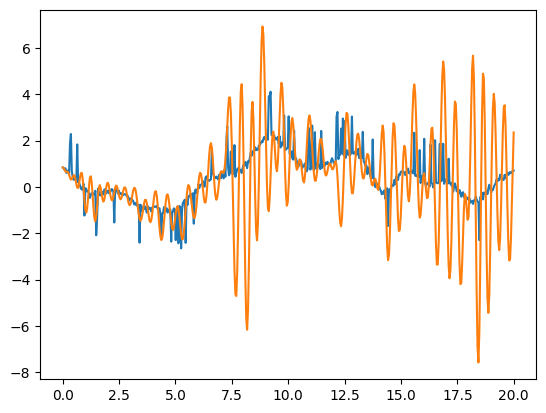

In [12]:

plt.plot(X,y)
plt.plot(X,model.mu_f)

In [13]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_SGP_WELSCH(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,structure="Tri", alpha=0.5,c_prop=2.5):
        super().__init__()
        self.X = X
        self.y = y
        self.N_u = inducing.shape[0]

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.c=tf.Variable(tf.sqrt(c_prop*tf.reduce_mean(self.y**2)),dtype=tf.float64,trainable=False)
        self.c_prop=c_prop
        
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        # GP parameters
        self.kernel = kernel
        self.inducing_variable = inducing
        self.mu_u = tf.Variable(tf.ones((self.N_u, 1), dtype=tf.float64))
        self.structure=structure

        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, self.X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            if self.structure == "Diag":
                Sigma_u = tf.linalg.diag(self.Var_q)
            else:
                Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
            
            identity = tf.eye(self.N_u, dtype=K.dtype)
            jitter = identity * 1e-6

            Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_u + jitter)
            ld_K = tf.linalg.logdet(K_uu+jitter)
            
            sigma_f=tf.linalg.diag_part(K-K_fu@K_uu_inv@K_uf+K_fu@K_uu_inv@Sigma_u@K_uu_inv@K_uf)
            mu_f=K_fu@K_uu_inv@self.mu_u

            # Loss terms
            term1 = tf.reduce_sum(self.c/2*(1-1/tf.math.sqrt(1+2*sigma_f/self.c**2)*tf.math.exp(-(mu_f-self.y)**2/(self.c**2+2*sigma_f))))
            term2 = self.alpha/2*tf.transpose(self.mu_u)@Sigma_a_inv@self.mu_u
            term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3)
        
        # Trainable parameters
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))
        #self.c.assign(tf.sqrt(self.c_prop*tf.reduce_mean((self.y-mu_f)**2/sigma_f)))
        return loss
    

    def train(self, max_steps=100, tolerance=0.00001, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
        
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

           

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])/abs(loss_history[-1]+ loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      
        
    def predict_out(self, Xnew):
        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)
        
        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)

    
N=X.shape[0]
Z = X[np.random.choice(N, 50, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_SGP_WELSCH(X, y,inducing_variable,kernel)
model.train(max_steps=100)
#opt = gpflow.optimizers.Scipy()
#opt.minimize(model.train_step, model.trainable_variables)

Training completed in 1.361 seconds.


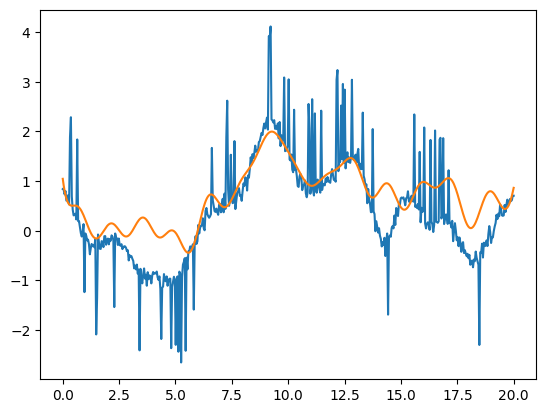

In [14]:
f,s=model.predict_out(X)
plt.plot(X,y)
plt.plot(X,f)

In [15]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
tfpk = tfp.math.psd_kernels

class GVI_SGP_T(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,structure="Tri", alpha=0.5,nu=2):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.inducing_variable = inducing
        self.N_u = inducing.shape[0]
        self.sigma=gpflow.Parameter(1.,trainable=False)
        
        self.nu=tf.constant(nu,dtype=tf.float64)
        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.kernel = kernel
        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    def predict_in(self):
        K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv) 
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv@ (self.y))

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u
        
    def predict_out(self, Xnew):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)
        
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, self.X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            if self.structure == "Diag":
                Sigma_u = tf.linalg.diag(self.Var_q)
            else:
                Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
            
            identity = tf.eye(self.N_u, dtype=K.dtype)
            jitter = identity * 1e-6

            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            
            precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv)
            q1 = tf.linalg.inv(precision_mid + jitter)
            q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv @ self.y) 
            mu_u = tf.matmul(q1, q2)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_u + jitter)
            ld_K = tf.linalg.logdet(K_uu+jitter)

            # Loss terms
            term1 = 0.5 *  tf.transpose(mu_u) @ (K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv+Sigma_a_inv) @ mu_u
            term2 = -  tf.transpose(mu_u)@K_uu_inv@K_uf@ Lambda_inv @ (self.y)
            term4 = 0.5  * tf.linalg.trace(K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv @ Sigma_u)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - K_fu@K_uu_inv@mu_u 
        num=self.nu+1
        denom=self.nu*self.sigma**2+tf.squeeze(residual)**2+tf.linalg.diag_part(K_fu@K_uu_inv@Sigma_u@K_uu_inv@K_uf)
        self.lambda_inv.assign(tf.squeeze((num / denom)))
         
        return loss
    

    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_SGP_T(X, y,inducing_variable,kernel)
model.train()

Step: 0 Loss: 7041.575166206463
Step: 1 Loss: 294.6417479931721
Step: 2 Loss: 290.07653374969084
Step: 3 Loss: 283.17726535128213
Step: 4 Loss: 275.97548618451066
Step: 5 Loss: 268.7287955561865
Step: 6 Loss: 261.4365806175765
Step: 7 Loss: 254.11334976699453
Step: 8 Loss: 246.77752661317103
Step: 9 Loss: 239.42893475051724
Step: 10 Loss: 232.06995101443425
Step: 11 Loss: 224.72155146596384
Step: 12 Loss: 217.42978078569573
Step: 13 Loss: 210.25836323284122
Step: 14 Loss: 203.27067233003334
Step: 15 Loss: 196.5070950749988
Step: 16 Loss: 189.98619233780028
Step: 17 Loss: 183.73295246187632
Step: 18 Loss: 177.7476988850435
Step: 19 Loss: 171.98458881319894
Step: 20 Loss: 166.41381932856623
Step: 21 Loss: 161.02611622606366
Step: 22 Loss: 155.82535470973687
Step: 23 Loss: 150.84213890686266
Step: 24 Loss: 146.10572855600964
Step: 25 Loss: 141.62351615378026
Step: 26 Loss: 137.39699899576027
Step: 27 Loss: 133.40604835739015
Step: 28 Loss: 129.6053312406233
Step: 29 Loss: 125.949636534308

In [16]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_L(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,Sigma_f_structure="c_f", alpha=0.5):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.N = tf.cast(X.shape[0],tf.float64)
        # GP parameters
        self.kernel = kernel
        self.inducing_variable = inducing
        self.b=gpflow.Parameter(1.,transform=gpflow.utilities.positive())
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        self.Sigma_f_structure = Sigma_f_structure

        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    @tf.function
    def update_mu_f(self, Sigma_a_inv, sigma_2,Lambda_inv):
        q1 = tf.linalg.inv(self.alpha * Sigma_a_inv + Lambda_inv / sigma_2)
        q2 = tf.matmul(Lambda_inv / sigma_2, self.y)
        return tf.matmul(q1, q2)
    
    def maximum_log_likelihood_objective(self):
        pass
        
    @tf.function
    def compute_sigma_f(self, X,Lambda_inv):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            K_inv=tf.linalg.inv(K+ tf.linalg.eye(K.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = self.c_f * tf.linalg.inv(
                    K_inv + Lambda_inv*self.b**(-2))
        else:
            K = self.kernel(X, X)
            K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f
    
    def predict_in(self):
        Lambda=tf.linalg.diag(1/self.lambda_inv)
        Lambda_inv= tf.linalg.diag(self.lambda_inv)
        K, Sigma_f = self.compute_sigma_f(self.X,Lambda)
        
        jitter = 1e-6 * tf.eye(tf.shape(K)[0], dtype=K.dtype)
        K_j = K + jitter

        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        self.mu_f = self.update_mu_f(Sigma_a_inv, self.b**2,Lambda_inv)
        self.Sigma_f=Sigma_f
        
    def predict_out(self,X):
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)
        
        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            Lambda_inv= tf.linalg.diag(self.lambda_inv)
            K, Sigma_f = self.compute_sigma_f(self.X,Lambda_inv)
            identity = tf.eye(K.shape[0], dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter


            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            mu_f = self.update_mu_f(Sigma_a_inv, self.b**2,Lambda_inv)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = 0.5 * self.b**(-2) * tf.transpose(mu_f) @ (Lambda_inv+Sigma_a_inv) @ mu_f
            term2 = -self.b**(-2) * tf.transpose(mu_f) @Lambda_inv @ (self.y)
            term3 = self.N* tf.math.log(self.b)
            term4 = 0.5 * self.b**(-2) * tf.linalg.trace(Lambda_inv @ Sigma_f)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - mu_f
        denom=tf.squeeze(residual)**2+tf.linalg.diag_part(Sigma_f)
        self.lambda_inv.assign(tf.squeeze((self.b**2 / denom)))
         
        return loss
    
    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            #tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_GP_L(X, y,inducing_variable,kernel,Sigma_f_structure="inducing")
model.train()

Early stopping at step 157: loss change < 0.5 for 5 steps.
Training completed in 8.326 seconds.


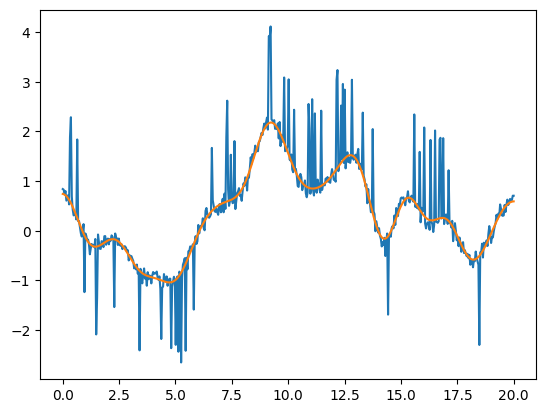

In [17]:
plt.plot(X,y)
model.predict_in()
plt.plot(X,model.mu_f)

In [18]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
tfpk = tfp.math.psd_kernels

class GVI_SGP_L(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,structure="Tri", alpha=0.5,nu=2):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.inducing_variable = inducing
        self.N_u = inducing.shape[0]
        self.b=gpflow.Parameter(1.,transform=gpflow.utilities.positive())
        
        self.nu=tf.constant(nu,dtype=tf.float64)
        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.kernel = kernel
        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    def predict_in(self):
        K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv) *self.b**(-2)
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv@ (self.y)*self.b**(-2))

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u
        
    def predict_out(self, Xnew):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)
        
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, self.X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            if self.structure == "Diag":
                Sigma_u = tf.linalg.diag(self.Var_q)
            else:
                Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
            
            identity = tf.eye(self.N_u, dtype=K.dtype)
            jitter = identity * 1e-6

            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            
            precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv)*self.b**(-2)
            q1 = tf.linalg.inv(precision_mid + jitter)
            q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv @ self.y*self.b**(-2)) 
            mu_u = tf.matmul(q1, q2)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_u + jitter)
            ld_K = tf.linalg.logdet(K_uu+jitter)

            # Loss terms
            term1 = 0.5 *  tf.transpose(mu_u) @ (K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv+Sigma_a_inv) @ mu_u*self.b**(-2)
            term2 = -  tf.transpose(mu_u)@K_uu_inv@K_uf@ Lambda_inv @ (self.y)*self.b**(-2)
            term4 = 0.5 * self.b**(-2) * tf.linalg.trace(K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv @ Sigma_u)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - K_fu@K_uu_inv@mu_u 
        denom=tf.squeeze(residual)**2+tf.linalg.diag_part(K_fu@K_uu_inv@Sigma_u@K_uu_inv@K_uf)
        self.lambda_inv.assign(tf.squeeze((1 / denom)))
         
        return loss
    

    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            #tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_SGP_L(X, y,inducing_variable,kernel)
model.train()

Training completed in 3.778 seconds.


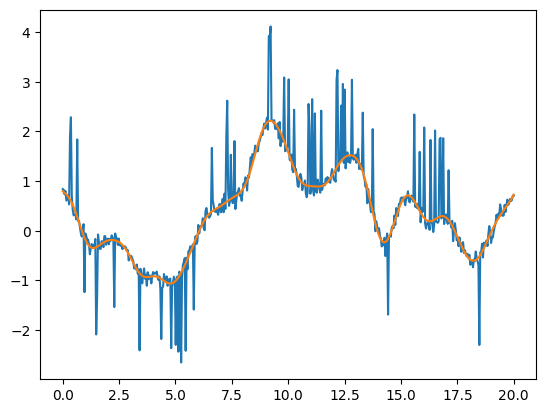

In [19]:
model.predict_in()
f,s=model.predict_out(X)
plt.plot(X,y)
plt.plot(X,model.predict_out(X)[0])

In [29]:
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
import numpy as np
import gpflow
from matplotlib import pyplot as plt


def generate_sample(
    n_points: int = 500,
    sigma_n: float = 0.1,
    heteroskedastic: bool = False,
    percent_output_outliers: float = 0.0,
    add_input_outliers: bool = False,
    n_input_outliers: int = 10,
    input_outlier_spread: float = 20.0,
    seed: int = 10,
    plot: bool = True
) -> tuple[np.ndarray, np.ndarray, np.ndarray, gpflow.kernels.Kernel]:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Kernel
    kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)

    # Original input and function
    x = np.linspace(0, 20, n_points).reshape(-1, 1)
    f = np.random.multivariate_normal(
        mean=np.zeros(n_points),
        cov=kernel(x, x) + 1e-8 * np.eye(n_points)
    ).reshape(-1, 1)

    # Noise: homoskedastic or heteroskedastic
    if heteroskedastic:
        # Example: noise increases linearly with x
        noise_scale = sigma_n * (1 + 0.1 * x.squeeze())
    else:
        noise_scale = sigma_n * np.ones(n_points)

    # ✅ Correct call: draw elementwise noise
    y_obs = f.squeeze() + np.random.normal(loc=0.0, scale=noise_scale)
    y_obs = y_obs.reshape(-1, 1)

    # Apply output outliers
    if percent_output_outliers > 0:
        i_mis = np.random.choice(n_points, int(percent_output_outliers * n_points), replace=False)
        factor = 10.0  # max absolute change
        y_obs[i_mis] += np.random.uniform(-factor, factor, size=(i_mis.size, 1))

    # Apply input outliers
    x_obs = x.copy()
    if add_input_outliers and n_input_outliers > 0:
        replace_idx = np.random.choice(n_points, n_input_outliers, replace=False)
        x_min, x_max = x.min(), x.max()

        x_outliers_low = np.random.uniform(
            low=x_min - input_outlier_spread,
            high=x_min - 0.1 * input_outlier_spread,
            size=(n_input_outliers // 2, 1)
        )
        x_outliers_high = np.random.uniform(
            low=x_max + 0.1 * input_outlier_spread,
            high=x_max + input_outlier_spread,
            size=(n_input_outliers - x_outliers_low.shape[0], 1)
        )
        x_outliers = np.vstack([x_outliers_low, x_outliers_high])
        x_obs[replace_idx] = x_outliers

    # Optional plotting
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(x, f, 'k--', lw=2, label='true f(x)')
        plt.plot(x_obs, y_obs, 'r.', ms=8, alpha=0.7, label='observed data')
        plt.legend()
        x_min_plot = x.min() - (input_outlier_spread if add_input_outliers else 0)
        x_max_plot = x.max() + (input_outlier_spread if add_input_outliers else 0)
        plt.xlim(x_min_plot, x_max_plot)
        title = "Generated GP Sample"
        if heteroskedastic:
            title += " (Heteroskedastic Noise)"
        else:
            title += " (Homoskedastic Noise)"
        plt.title(title)
        plt.show()

    return x_obs, y_obs, f, kernel


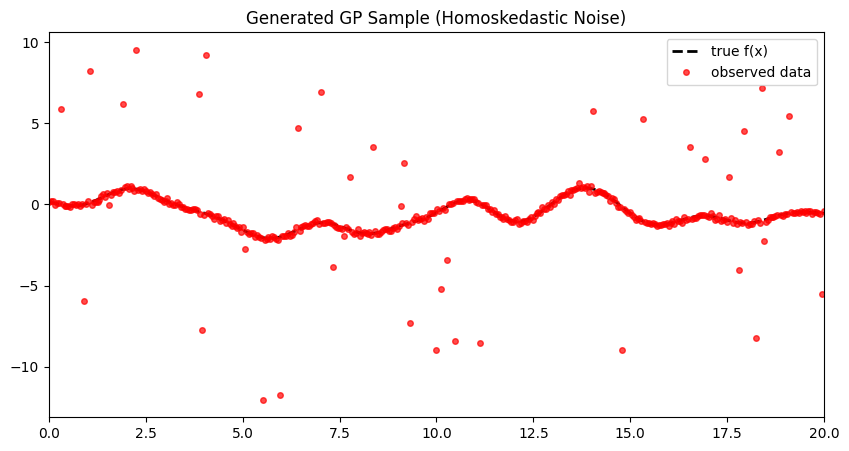

In [30]:
X, y, f, kernel_from_data = generate_sample(
            seed=seed,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=N
        )

In [72]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import w  # assuming your weighting function is in module w
from model_altamirano import RCGPR, RCSGPR

cases = [
    [0.0, False, False],   # clean, homoskedastic
    [0.1, False, False]   # output outliers only
]
seeds = [1,2,3]
N = 400

results = []  # will store dicts {case, seed, model, value}

# helper
def save_result(case, seed, model_name, value):
    if value is None:
        return
    val = float(value)
    # exclude >1 right away if you prefer (or keep and filter later)
    if val <= 1:
        results.append({
            "case": case,
            "seed": seed,
            "model": model_name,
            "value": val
        })

# --- Main loops ---
for ci, (perc, input_o, hetero) in enumerate(cases):
    for seed in seeds:
        # generate data
        X, y, f, kernel_from_data = generate_sample(
            seed=seed, plot=False,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=N
        )
        
        Z = np.linspace(np.min(X), np.max(X), 50)[:, None]
        inducing_variable = gpflow.Parameter(Z, trainable=False)
        
        
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y, kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)))
            model.internal_opt()
            model.predict_ins()
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")
        """ 
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y, kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)), objective="predictive", lambda_method="predictive")
            model.internal_opt()
            model.predict_ins()
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y, kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)), Sigma_f_structure="inducing",inducing=inducing_variable)
            model.internal_opt()
            model.predict_ins()
            save_result(ci, seed, "GVI_RCGP_alpha_Inducing", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha inducing failed: {e}")
        """ 
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_SRCGPR_alpha(X, y, inducing_variable,kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)),sigma=0.01)
            model.internal_opt()
            model.predict_ins()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")
            
        """ 
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_GP_T(X, y, inducing_variable,kernel)
            model.train(max_steps=500)
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_GP_T", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")
            
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_GP_T(X, y, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train(max_steps=500)
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_GP_T_ind", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_SGP_T(X, y, inducing_variable, kernel)
            model.train(max_steps=500)
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SGP_T", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_T failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_GP_L(X, y, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train(max_steps=500)
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_GP_L_ind", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_GP_L(X, y, inducing_variable,kernel)
            model.train(max_steps=500)
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_GP_L", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_SGP_L(X, y, inducing_variable, kernel)
            model.train(max_steps=500)
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")
        
        try:
            N = X.shape[0]
            Z = X[np.random.choice(N, 50, replace=False), :]
            inducing_variable = gpflow.Parameter(Z, trainable=True)
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_GP_WELSCH(X, y, inducing_variable,kernel)
            model.train(max_steps=500)
            save_result(ci, seed, "GVI_GP_WELSCH", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")
          
        try:  
            N = X.shape[0]
            Z = X[np.random.choice(N, 50, replace=False), :]
            inducing_variable = gpflow.Parameter(Z, trainable=True)
            model = GVI_SGP_WELSCH(X, y, inducing_variable,kernel)
            model.train(max_steps=2000)
            mu_f,s=model.predict_out(X)
            save_result(ci, seed, "GVI_SGP_WELSCH", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_WELSCH failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y,kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)),inducing=inducing_variable)
            model.internal_opt()
            model.predict_ins()
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y,kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)), objective="predictive",  inducing=inducing_variable, lambda_method="predictive")
            model.internal_opt()
            model.predict_ins()
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")
        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y,kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)), Sigma_f_structure="inducing",inducing=inducing_variable)
            model.internal_opt()
            model.predict_ins()
            save_result(ci, seed, "GVI_RCGP_alpha_Inducing", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha inducing failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_SRCGPR_alpha(X, y,inducing_variable,kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)))
            model.internal_opt()
            model.predict_ins()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")
        
        try:
            standard_gp = gpflow.models.GPR(
                        (X, y),
                    kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01,variance = 0.01),
                    noise_variance = 0.01
                    )
             
            opt = gpflow.optimizers.Scipy()
            opt_options = dict()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables, options=opt_options)
            f_mean, f_var = standard_gp.predict_f(X, full_cov=False)
            save_result(ci, seed, "GPR", tf.reduce_mean((f - f_mean) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")     
        """ 


        
            

# --- Convert to DataFrame for analysis ---
df = pd.DataFrame(results)

# --- Compute averages over seeds ---
summary = df.groupby(["case", "model"]).agg(
    mean=("value", "median"),
    
    std=("value", "std"),
    n=("value", "count")
).reset_index()



2025-09-30 17:32:53.063589: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_train_step_5370173}}{{node MatrixInverse_2}}]]


GVI_SRCGPR_alpha failed: Graph execution error:

Detected at node MatrixInverse_2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Py

In [64]:
summary = df.groupby(["case", "model"]).agg(
    min=("value", "min"),
    
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary)

   case             model       min       std  n
0     0          GVI_GP_L  0.001361  0.000273  3
1     0  GVI_SRCGPR_alpha  0.051520  0.013490  3
2     1          GVI_GP_L  0.001119  0.000330  2
3     1  GVI_SRCGPR_alpha  0.473838  0.367425  2


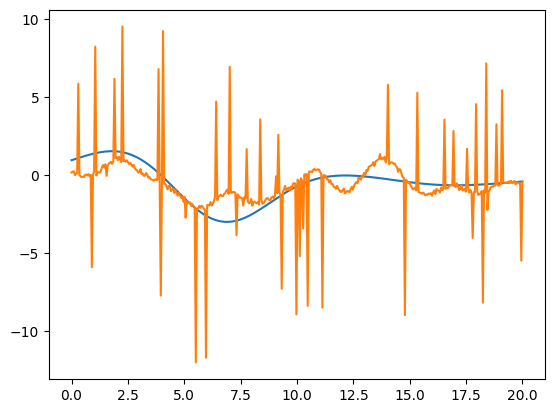

In [71]:
plt.plot(X,mu_f)
plt.plot(X,y)

In [46]:
# --- Compute averages over seeds ---
summary = df.groupby(["case", "model"]).agg(
    median=("value", "min"),
    
    std=("value", "std"),
    n=("value", "count")
).reset_index()

s=summary

In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import w  # assuming your weighting function is in module w
from model_altamirano import RCGPR, RCSGPR

cases = [
    [0.0, False, False],   # clean, homoskedastic
    [0.1, False, False],   # output outliers only
]
seeds = [1,2,3,4,5]
N = 400

results = []  # will store dicts {case, seed, model, value}

# helper
def save_result(case, seed, model_name, value):
    if value is None:
        return
    val = float(value)
    # exclude >1 right away if you prefer (or keep and filter later)
    if val <= 1:
        results.append({
            "case": case,
            "seed": seed,
            "model": model_name,
            "value": val
        })

# --- Main loops ---
for ci, (perc, input_o, hetero) in enumerate(cases):
    for seed in seeds:
        # generate data
        X, y, f, kernel_from_data = generate_sample(
            seed=seed, plot=False,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=N
        )

        Z = np.linspace(np.min(X), np.max(X), 50)[:, None]
        inducing_variable = gpflow.Parameter(Z, trainable=False)



        try:
            model = RCSGPR(
                (X, y),
                kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01, variance=0.01),
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_obs), 0.95)),
                noise_variance=0.01,
                inducing_variable=inducing_variable
            )
            gpflow.set_trainable(model.likelihood.variance, False)
            opt = gpflow.optimizers.Scipy()
            log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
            f_mean, _ = model.predict_f(X, full_cov=False)
            save_result(ci, seed, "RCSGPR", tf.reduce_mean((f - f_mean) ** 2))
        except Exception as e:
            print(f"RCSGPR failed: {e}")

      


        
            

# --- Convert to DataFrame for analysis ---
df = pd.DataFrame(results)

# --- Compute averages over seeds ---
summary = df.groupby(["case", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary)


   case   model      mean       std  n
0     0  RCSGPR  0.024829  0.004872  5
1     1  RCSGPR  0.054588  0.016707  5


In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import w  # assuming your weighting function is in module w
from model_altamirano import RCGPR, RCSGPR

cases = [
    [0.0, False, False],   # clean, homoskedastic
    [0.1, False, False],   # output outliers only
]
seeds = [1,2,3,4,5]
N = 400

results = []  # will store dicts {case, seed, model, value}

# helper
def save_result(case, seed, model_name, value):
    if value is None:
        return
    val = float(value)
    # exclude >1 right away if you prefer (or keep and filter later)
    if val <= 1:
        results.append({
            "case": case,
            "seed": seed,
            "model": model_name,
            "value": val
        })

# --- Main loops ---
for ci, (perc, input_o, hetero) in enumerate(cases):
    for seed in seeds:
        # generate data
        X, y, f, kernel_from_data = generate_sample(
            seed=seed, plot=False,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=N
        )

        Z = np.linspace(np.min(X), np.max(X), 50)[:, None]
        inducing_variable = gpflow.Parameter(Z, trainable=False)


        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_SRCGPR_alpha(X, y, inducing_variable,kernel,w.IMQ(C=np.quantile(np.abs(y), 0.95)),structure="Tri")
            model.internal_opt()
            model.predict_ins()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")


        
            

# --- Convert to DataFrame for analysis ---
df = pd.DataFrame(results)

# --- Compute averages over seeds ---
summary = df.groupby(["case", "model"]).agg(
    mean=("value", "median"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary)


   case             model      mean       std  n
0     0  GVI_SRCGPR_alpha  0.099284  0.031642  5
1     1  GVI_SRCGPR_alpha  0.190216  0.072366  5


In [18]:
summary = df.groupby(["case", "model"]).agg(
    median=("value", "median"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

In [19]:
summary

,case,model,median,std,n
0,0,GVI_SRCGPR_alpha,0.097830,0.031642,5
1,1,GVI_SRCGPR_alpha,0.201916,0.072366,5


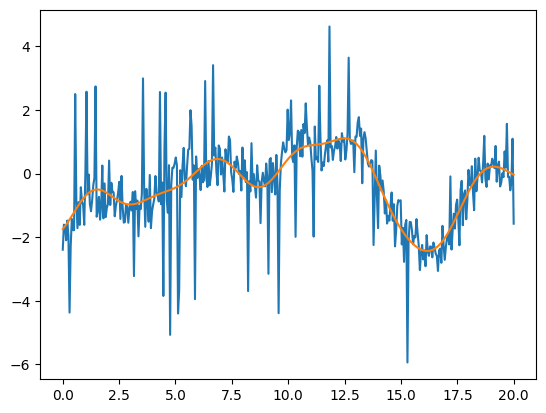

In [27]:
from model_altamirano import RCGPR, RCSGPR

standard_gp = gpflow.models.GPR(
    (X, y),
kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01,variance = 0.01),
noise_variance = 0.01
)

opt = gpflow.optimizers.Scipy()
opt_options = dict()
res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables, options=opt_options)
f_mean, f_var = standard_gp.predict_f(X, full_cov=False)
plt.plot(X,y)
plt.plot(X,f_mean)

In [55]:
summary

,case,model,mean,std,n
0,0,RCGPR,0.009306,0.000483,3
1,0,RCSGPR,0.010892,0.000411,3


In [58]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split
import w  # weighting function module
from sklearn.preprocessing import StandardScaler
from model_altamirano import RCGPR, RCSGPR


# ==== Dataset loaders ====
def load_concrete_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_energy_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values
    return X, y

def load_yacht_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
    df = pd.read_csv(url, delim_whitespace=True, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_boston_dataset():
    data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
    columns = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
        "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
    ]
    df = pd.read_csv(data_url, sep=r"\s+", header=None, names=columns)
    X = df.drop("MEDV", axis=1).values
    y = df["MEDV"].values
    return X, y

# ==== Inject output outliers ====
def add_output_outliers(y, perc, seed):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_out = int(len(y) * perc)
    if n_out > 0:
        idx = rng.choice(len(y), n_out, replace=False)
        sigma = np.std(y)
        # Uniform noise between 3σ and 5σ
        noise = rng.uniform(low=3*sigma, high=5*sigma, size=(n_out, 1))
        # Randomly flip half of them negative to mimic "uniform" contamination
        signs = rng.choice([-1, 1], size=(n_out, 1))
        noise *= signs
        y_noisy[idx, 0] += noise[:, 0]
    return y_noisy


# ==== Store results ====
results = []
def save_result(dataset, seed, model_name, value):
    results.append({
        "dataset": dataset,
        "seed": seed,
        "model": model_name,
        "value": float(value)
    })

# ==== Experiments ====
datasets = {
    "Energy": load_energy_dataset,
    "Yacht": load_yacht_dataset,
    "Boston": load_boston_dataset
}
seeds = [97]
perc = 0.1  # 10% outliers
test_ratio = 0.2  # 4:1 split

for dname, loader in datasets.items():
    X, y = loader()
    ci=dname
    
    gpflow.config.set_default_float(np.float64)
    
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = np.asarray(y).reshape(-1, 1).astype(np.float64)

    for seed in seeds:
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_ratio, random_state=seed
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test= scaler.transform(X_test)

        # add output outliers only in the training set
        y_train_out = add_output_outliers(y_train, perc, seed)
        #y_train_out = y_train
        
        rng = np.random.default_rng(seed)
        idx = rng.choice(X_train.shape[0], 50, replace=False)
        Z = X_train[idx]

        inducing_variable = gpflow.Parameter(Z, trainable=True)
        sigma_start=1.
        # === Run models ===
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = gpflow.models.GPR(
                (X_train, y_train_out),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "GPR", tf.reduce_mean((y_test - f_mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"GPR failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = RCGPR(
                (X_train, y_train_out),
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCGPR", tf.reduce_mean((y_test - f_mean) ** 2))
        except Exception as e:
            print(f"RCGPR failed: {e}")


            
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), objective="predictive", lambda_method="predictive")
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - y_test) ** 2))
            sigma_start = model.sigma
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")
            
            
        try:
            
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((y_test - f) ** 2))
                    
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")
        """      
        try:
           
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), Sigma_f_structure="inducing",inducing=inducing_variable, sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_Inducing", tf.reduce_mean((f - y_test) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha inducing failed: {e}")
        """
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = RCSGPR(
                (X_train, y_train_out),
                kernel=kernel,
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                noise_variance=0.01,
                inducing_variable=inducing_variable
            )
            gpflow.set_trainable(model.likelihood.variance, False)
            opt = gpflow.optimizers.Scipy()
            log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
            f_mean, _ = model.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCSGPR", tf.reduce_mean((y_test- f_mean) ** 2))
            kernel1 = kernel
            sigma_start = tf.sqrt(model.likelihood.variance.numpy())
        except Exception as e:
            print(f"RCSGPR failed: {e}")
            
            
        try:
     
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SRCGPR_alpha(X_train, y_train_out, inducing_variable,kernel1,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")
            
        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational GP
            model = gpflow.models.VGP((X_train, y_train_out), kernel=kernel, likelihood=likelihood)
            
            # Train
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.training_loss, model.trainable_variables)
            
            mean, var = model.predict_f(X_test)
            save_result(ci, seed, "student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")

        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")
            
        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T_ind", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")

        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational Sparse GP (SVGP)
            model = gpflow.models.SVGP(kernel=kernel,
                                       likelihood=likelihood,
                                       inducing_variable=Z)
            
            # Training with minibatch stochastic optimization
            data = (X_train, y_train_out)
            training_loss = model.training_loss_closure(data)
            
            opt = gpflow.optimizers.Scipy()
            opt.minimize(training_loss, model.trainable_variables)
            
            # Predictions
            mean, var = model.predict_f(X_test)

            save_result(ci, seed, "sparse student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")


        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_T(X_train, y_train_out, inducing_variable, kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_T failed: {e}")

        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_L(X_train, y_train_out, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_L_ind", tf.reduce_mean((y - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_L(X_train, y_train_out, inducing_variable, kernel)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=500)
            mu_f=model.predict(X_test)
            save_result(ci, seed, "GVI_GP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")

          
        try:  
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=2000)
            mu_f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_WELSCH failed: {e}")


            


        
        
        
        
# === Aggregate results ===
df = pd.DataFrame(results)
summary = df.groupby(["dataset", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary) 


2025-09-14 19:53:26.897317: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_training_loss_2166399}}{{node MatrixInverse}}]]


RCGPR failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framewor

2025-09-14 20:04:57.462430: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-09-14 20:04:57.561164: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_compute_sigma_f_2265469}}{{node MatrixInverse}}]]


GVI_GP_T failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.frame

2025-09-14 20:06:10.968475: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [768,1] vs. [154,1]


...

GVI_RCGP_alpha failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python

2025-09-14 20:12:13.075008: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-09-14 20:12:13.108695: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_compute_sigma_f_2635482}}{{node MatrixInverse}}]]


GVI_GP_T failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.frame

2025-09-14 20:12:42.508467: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [506,1] vs. [102,1]


Training completed in 2.549 seconds.
Training completed in 14.400 seconds.
Training completed in 12.775 seconds.
   dataset                      model         mean  std  n
0   Boston                        GPR   205.067905  NaN  1
1   Boston                   GVI_GP_T     5.337906  NaN  1
2   Boston              GVI_GP_WELSCH  2569.653354  NaN  1
3   Boston                  GVI_SGP_L    81.754913  NaN  1
4   Boston                  GVI_SGP_T    11.823902  NaN  1
5   Boston             GVI_SGP_WELSCH    58.108532  NaN  1
6   Boston           GVI_SRCGPR_alpha   294.612948  NaN  1
7   Boston                      RCGPR   120.860333  NaN  1
8   Boston                     RCSGPR   251.997756  NaN  1
9   Boston           sparse student-t     7.862464  NaN  1
10  Boston                  student-t     7.915870  NaN  1
11  Energy                        GPR   227.137936  NaN  1
12  Energy                   GVI_GP_T     0.232973  NaN  1
13  Energy              GVI_GP_WELSCH   291.320062  NaN  1
14

In [59]:
summary

,dataset,model,mean,std,n
0,Boston,GPR,205.067905,NaN,1
1,Boston,GVI_GP_T,5.337906,NaN,1
2,Boston,GVI_GP_WELSCH,2569.653354,NaN,1
3,Boston,GVI_SGP_L,81.754913,NaN,1
4,Boston,GVI_SGP_T,11.823902,NaN,1
5,Boston,GVI_SGP_WELSCH,58.108532,NaN,1
6,Boston,GVI_SRCGPR_alpha,294.612948,NaN,1
7,Boston,RCGPR,120.860333,NaN,1
8,Boston,RCSGPR,251.997756,NaN,1
9,Boston,sparse student-t,7.862464,NaN,1


In [60]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split
import w  # weighting function module
from sklearn.preprocessing import StandardScaler
from model_altamirano import RCGPR, RCSGPR


# ==== Dataset loaders ====
def load_concrete_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_energy_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values
    return X, y

def load_yacht_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
    df = pd.read_csv(url, delim_whitespace=True, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_boston_dataset():
    data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
    columns = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
        "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
    ]
    df = pd.read_csv(data_url, sep=r"\s+", header=None, names=columns)
    X = df.drop("MEDV", axis=1).values
    y = df["MEDV"].values
    return X, y

# ==== Inject output outliers ====
def add_output_outliers(y, perc, seed):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_out = int(len(y) * perc)
    if n_out > 0:
        idx = rng.choice(len(y), n_out, replace=False)
        sigma = np.std(y)
        # Uniform noise between 3σ and 5σ
        noise = rng.uniform(low=3*sigma, high=5*sigma, size=(n_out, 1))
        # Randomly flip half of them negative to mimic "uniform" contamination
        signs = rng.choice([-1, 1], size=(n_out, 1))
        noise *= signs
        y_noisy[idx, 0] += noise[:, 0]
    return y_noisy


# ==== Store results ====
results = []
def save_result(dataset, seed, model_name, value):
    results.append({
        "dataset": dataset,
        "seed": seed,
        "model": model_name,
        "value": float(value)
    })

# ==== Experiments ====
datasets = {
    "Energy": load_energy_dataset,
    "Yacht": load_yacht_dataset,
    "Boston": load_boston_dataset
}
seeds = [97]
perc = 0.1  # 10% outliers
test_ratio = 0.2  # 4:1 split

for dname, loader in datasets.items():
    X, y = loader()
    ci=dname
    
    gpflow.config.set_default_float(np.float64)
    
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = np.asarray(y).reshape(-1, 1).astype(np.float64)

    for seed in seeds:
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_ratio, random_state=seed
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test= scaler.transform(X_test)
        
        y_train = scaler.fit_transform(y_train)
        y_test = scaler.transform(y_test)

        # add output outliers only in the training set
        y_train_out = add_output_outliers(y_train, perc, seed)
        #y_train_out = y_train
        
        rng = np.random.default_rng(seed)
        idx = rng.choice(X_train.shape[0], 50, replace=False)
        Z = X_train[idx]

        inducing_variable = gpflow.Parameter(Z, trainable=True)
        sigma_start=1.
        # === Run models ===
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = gpflow.models.GPR(
                (X_train, y_train_out),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "GPR", tf.reduce_mean((y_test - f_mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"GPR failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = RCGPR(
                (X_train, y_train_out),
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCGPR", tf.reduce_mean((y_test - f_mean) ** 2))
        except Exception as e:
            print(f"RCGPR failed: {e}")


            
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), objective="predictive", lambda_method="predictive")
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - y_test) ** 2))
            sigma_start = model.sigma
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")
            
            
        try:
            
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((y_test - f) ** 2))
                    
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")
        """      
        try:
           
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), Sigma_f_structure="inducing",inducing=inducing_variable, sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_Inducing", tf.reduce_mean((f - y_test) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha inducing failed: {e}")
        """
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = RCSGPR(
                (X_train, y_train_out),
                kernel=kernel,
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                noise_variance=0.01,
                inducing_variable=inducing_variable
            )
            gpflow.set_trainable(model.likelihood.variance, False)
            opt = gpflow.optimizers.Scipy()
            log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
            f_mean, _ = model.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCSGPR", tf.reduce_mean((y_test- f_mean) ** 2))
            kernel1 = kernel
            sigma_start = tf.sqrt(model.likelihood.variance.numpy())
        except Exception as e:
            print(f"RCSGPR failed: {e}")
            
            
        try:
     
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SRCGPR_alpha(X_train, y_train_out, inducing_variable,kernel1,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")
            
        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational GP
            model = gpflow.models.VGP((X_train, y_train_out), kernel=kernel, likelihood=likelihood)
            
            # Train
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.training_loss, model.trainable_variables)
            
            mean, var = model.predict_f(X_test)
            save_result(ci, seed, "student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")

        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")
            
        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T_ind", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")

        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational Sparse GP (SVGP)
            model = gpflow.models.SVGP(kernel=kernel,
                                       likelihood=likelihood,
                                       inducing_variable=Z)
            
            # Training with minibatch stochastic optimization
            data = (X_train, y_train_out)
            training_loss = model.training_loss_closure(data)
            
            opt = gpflow.optimizers.Scipy()
            opt.minimize(training_loss, model.trainable_variables)
            
            # Predictions
            mean, var = model.predict_f(X_test)

            save_result(ci, seed, "sparse student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")


        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_T(X_train, y_train_out, inducing_variable, kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_T failed: {e}")

        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_L(X_train, y_train_out, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_L_ind", tf.reduce_mean((y - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_L(X_train, y_train_out, inducing_variable, kernel)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=500)
            mu_f=model.predict(X_test)
            save_result(ci, seed, "GVI_GP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")

          
        try:  
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=2000)
            mu_f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_WELSCH failed: {e}")


            


        
        
        
        
# === Aggregate results ===
df = pd.DataFrame(results)
summary = df.groupby(["dataset", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary) 


2025-09-14 22:19:56.934112: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-09-14 22:20:20.424058: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-09-14 22:20:20.452844: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-09-14 22:20:20.456571: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: -139.49250864453282
Step: 1 Loss: -169.22144950131718
Step: 2 Loss: -174.16675464679088
Step: 3 Loss: -174.23183699866655
Step: 4 Loss: -174.30474249043922
Step: 5 Loss: -174.38672869893566
Step: 6 Loss: -174.4732477620994
Step: 7 Loss: -174.56183980512756
Step: 8 Loss: -174.6509868826632
Step: 9 Loss: -174.7396062422489
Step: 10 Loss: -174.82685285476566
Step: 11 Loss: -174.91202668176697
Step: 12 Loss: -174.99453020822853
Step: 13 Loss: -175.0738524874689
Step: 14 Loss: -175.14957120535234
Step: 15 Loss: -175.22136176316602
Step: 16 Loss: -175.2890098703322
Step: 17 Loss: -175.35241750443686
Step: 18 Loss: -175.41160245753147
Step: 19 Loss: -175.46668791600015
Step: 20 Loss: -175.517888832817
Step: 21 Loss: -175.56549507294298
Step: 22 Loss: -175.6098571646188
Step: 23 Loss: -175.65137470959624
Step: 24 Loss: -175.69048623396247
Step: 25 Loss: -175.7276592629327
Early stopping at step 25: loss change < 0.05 for 5 steps.
Training com

2025-09-14 22:33:58.482601: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [768,1] vs. [154,1]


Training completed in 3.073 seconds.
Training completed in 54.749 seconds.
Training completed in 18.101 seconds.


/var/folders/3j/3sftgpw558d6tvmshw2b29jc0000gn/T/ipykernel_2902/1470138319.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: -35.99292924020956
Step: 1 Loss: -52.8648909230904
Step: 2 Loss: -63.01186629354983
Step: 3 Loss: -64.57236970763307
Step: 4 Loss: -64.99111199749693
Step: 5 Loss: -65.23654775971016
Step: 6 Loss: -65.45752016283112
Step: 7 Loss: -65.67642897655189
Step: 8 Loss: -65.89610839949056
Step: 9 Loss: -66.11650501538927
Step: 10 Loss: -66.33724022527201
Step: 11 Loss: -66.55797003836939
Step: 12 Loss: -66.77841593805101
Step: 13 Loss: -66.998353891255
Step: 14 Loss: -67.21760300770032
Step: 15 Loss: -67.43601727249546
Step: 16 Loss: -67.65348047644927
Step: 17 Loss: -67.86990247724357
Step: 18 Loss: -68.08521682681554
Step: 19 Loss: -68.29937896780059
Step: 20 Loss: -68.51236508187488
Step: 21 Loss: -68.72417114640531
Step: 22 Loss: -68.93481323578482
Step: 23 Loss: -69.14432800945919
Step: 24 Loss: -69.35277504382658
Step: 25 Loss: -69.56023918202169
Step: 26 Loss: -69.76683391388326
Step: 27 Loss: -69.9727036280534
Step: 28 Loss: -70.17802

2025-09-14 22:37:34.242571: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [308,1] vs. [62,1]


Early stopping at step 5: loss change < 0.5 for 5 steps.
Training completed in 0.815 seconds.
Early stopping at step 70: loss change < 1e-05 for 5 steps.
Training completed in 1.211 seconds.
Training completed in 7.610 seconds.
<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: -94.63645763008324
Step: 1 Loss: -120.52571502957441
Step: 2 Loss: -121.51216698295613
Step: 3 Loss: -121.6395496091277
Step: 4 Loss: -121.74929389160397
Step: 5 Loss: -121.8989844906121
Step: 6 Loss: -122.06993850046419
Step: 7 Loss: -122.24859336926973
Step: 8 Loss: -122.42911112086583
Step: 9 Loss: -122.60953587410229
Step: 10 Loss: -122.78950565576449
Step: 11 Loss: -122.96926035077797
Step: 12 Loss: -123.14923610869411
Step: 13 Loss: -123.32989078308881
Step: 14 Loss: -123.5116204040676
Step: 15 Loss: -123.69471666286194
Step: 16 Loss: -123.87934864110153
Step: 17 Loss: -124.06556170596838
Step: 18 Loss: -124.25328870066278
Step: 19 Loss: -124.44236854219047
Step: 20 Loss: -124.63256818652164
Step: 21 Loss

2025-09-14 22:41:19.726653: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [506,1] vs. [102,1]


Early stopping at step 5: loss change < 0.5 for 5 steps.
Training completed in 0.814 seconds.
Training completed in 15.115 seconds.
Training completed in 12.488 seconds.
   dataset                      model       mean  std  n
0   Boston                        GPR   1.114982  NaN  1
1   Boston                   GVI_GP_T   0.081984  NaN  1
2   Boston               GVI_GP_T_ind   0.187219  NaN  1
3   Boston              GVI_GP_WELSCH   2.714295  NaN  1
4   Boston             GVI_RCGP_alpha   0.145004  NaN  1
5   Boston  GVI_RCGP_alpha_predictive   0.665560  NaN  1
6   Boston                  GVI_SGP_L   1.167574  NaN  1
7   Boston                  GVI_SGP_T   0.075375  NaN  1
8   Boston             GVI_SGP_WELSCH   0.731727  NaN  1
9   Boston           GVI_SRCGPR_alpha   1.156929  NaN  1
10  Boston                      RCGPR   1.206323  NaN  1
11  Boston                     RCSGPR   0.775989  NaN  1
12  Boston           sparse student-t   0.099719  NaN  1
13  Boston                  stud

In [62]:
print(summary)

   dataset                      model       mean  std  n
0   Boston                        GPR   1.114982  NaN  1
1   Boston                   GVI_GP_T   0.081984  NaN  1
2   Boston               GVI_GP_T_ind   0.187219  NaN  1
3   Boston              GVI_GP_WELSCH   2.714295  NaN  1
4   Boston             GVI_RCGP_alpha   0.145004  NaN  1
5   Boston  GVI_RCGP_alpha_predictive   0.665560  NaN  1
6   Boston                  GVI_SGP_L   1.167574  NaN  1
7   Boston                  GVI_SGP_T   0.075375  NaN  1
8   Boston             GVI_SGP_WELSCH   0.731727  NaN  1
9   Boston           GVI_SRCGPR_alpha   1.156929  NaN  1
10  Boston                      RCGPR   1.206323  NaN  1
11  Boston                     RCSGPR   0.775989  NaN  1
12  Boston           sparse student-t   0.099719  NaN  1
13  Boston                  student-t   0.097840  NaN  1
14  Energy                        GPR   0.515130  NaN  1
15  Energy                   GVI_GP_T   0.015278  NaN  1
16  Energy               GVI_GP

In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split
import w  # weighting function module
from sklearn.preprocessing import StandardScaler
from model_altamirano import RCGPR, RCSGPR


# ==== Dataset loaders ====
def load_concrete_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_energy_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values
    return X, y

def load_yacht_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
    df = pd.read_csv(url, delim_whitespace=True, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_boston_dataset():
    data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
    columns = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
        "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
    ]
    df = pd.read_csv(data_url, sep=r"\s+", header=None, names=columns)
    X = df.drop("MEDV", axis=1).values
    y = df["MEDV"].values
    return X, y

# ==== Inject output outliers ====
def add_output_outliers(y, perc, seed):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_out = int(len(y) * perc)
    if n_out > 0:
        idx = rng.choice(len(y), n_out, replace=False)
        sigma = np.std(y)
        # Uniform noise between 3σ and 5σ
        noise = rng.uniform(low=3*sigma, high=5*sigma, size=(n_out, 1))
        # Randomly flip half of them negative to mimic "uniform" contamination
        signs = rng.choice([-1, 1], size=(n_out, 1))
        noise *= signs
        y_noisy[idx, 0] += noise[:, 0]
    return y_noisy


# ==== Store results ====
results = []
def save_result(dataset, seed, model_name, value):
    results.append({
        "dataset": dataset,
        "seed": seed,
        "model": model_name,
        "value": float(value)
    })

# ==== Experiments ====
datasets = {
    "Concrete": load_concrete_dataset,
        "Energy": load_energy_dataset,
    "Yacht": load_yacht_dataset,
    "Boston": load_boston_dataset
}
seeds = [97,98,99,100,101]
perc = 0.1  # 10% outliers
test_ratio = 0.2  # 4:1 split

for dname, loader in datasets.items():
    X, y = loader()
    ci=dname
    
    gpflow.config.set_default_float(np.float64)
    
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = np.asarray(y).reshape(-1, 1).astype(np.float64)

    for seed in seeds:
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_ratio, random_state=seed
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test= scaler.transform(X_test)
        
        y_train = scaler.fit_transform(y_train)
        y_test = scaler.transform(y_test)

        # add output outliers only in the training set
        y_train_out = add_output_outliers(y_train, perc, seed)
        #y_train_out = y_train
        
        rng = np.random.default_rng(seed)
        idx = rng.choice(X_train.shape[0], 50, replace=False)
        Z = X_train[idx]

        inducing_variable = gpflow.Parameter(Z, trainable=False)
        sigma_start=1.
        # === Run models ===
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = gpflow.models.GPR(
                (X_train, y_train_out),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "GPR", tf.reduce_mean((y_test - f_mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"GPR failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = RCGPR(
                (X_train, y_train_out),
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCGPR", tf.reduce_mean((y_test - f_mean) ** 2))
        except Exception as e:
            print(f"RCGPR failed: {e}")


            
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), objective="predictive", lambda_method="predictive")
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - y_test) ** 2))
            sigma_start = model.sigma
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")
            
            
        try:
            
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((y_test - f) ** 2))
                    
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")
            
        try:
           
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), Sigma_f_structure="inducing",inducing=inducing_variable, sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_Inducing", tf.reduce_mean((f - y_test) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha inducing failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = RCSGPR(
                (X_train, y_train_out),
                kernel=kernel,
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                noise_variance=0.01,
                inducing_variable=inducing_variable
            )
            gpflow.set_trainable(model.likelihood.variance, False)
            opt = gpflow.optimizers.Scipy()
            log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
            f_mean, _ = model.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCSGPR", tf.reduce_mean((y_test- f_mean) ** 2))
            kernel1 = kernel
            sigma_start = tf.sqrt(model.likelihood.variance.numpy())
        except Exception as e:
            print(f"RCSGPR failed: {e}")
            
            
        try:
     
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SRCGPR_alpha(X_train, y_train_out, inducing_variable,kernel1,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")
            
        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational GP
            model = gpflow.models.VGP((X_train, y_train_out), kernel=kernel, likelihood=likelihood)
            
            # Train
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.training_loss, model.trainable_variables)
            
            mean, var = model.predict_f(X_test)
            save_result(ci, seed, "student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")

        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")
            
        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T_ind", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")

        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational Sparse GP (SVGP)
            model = gpflow.models.SVGP(kernel=kernel,
                                       likelihood=likelihood,
                                       inducing_variable=Z)
            
            # Training with minibatch stochastic optimization
            data = (X_train, y_train_out)
            training_loss = model.training_loss_closure(data)
            
            opt = gpflow.optimizers.Scipy()
            opt.minimize(training_loss, model.trainable_variables)
            
            # Predictions
            mean, var = model.predict_f(X_test)

            save_result(ci, seed, "sparse student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")


        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_T(X_train, y_train_out, inducing_variable, kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_T failed: {e}")

        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_L(X_train, y_train_out, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_L_ind", tf.reduce_mean((y - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_L(X_train, y_train_out, inducing_variable, kernel)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=500)
            mu_f=model.predict(X_test)
            save_result(ci, seed, "GVI_GP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")

          
        try:  
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=2000)
            mu_f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_WELSCH failed: {e}")

        
            


        
        
        
        
# === Aggregate results ===
df = pd.DataFrame(results)
summary = df.groupby(["dataset", "model"]).agg(
    median=("value", "median"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary) 


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: -229.02597977539273
Step: 1 Loss: -254.0302449179689
Step: 2 Loss: -261.14726858219956
Step: 3 Loss: -262.3983326628661
Step: 4 Loss: -262.8388861398652
Step: 5 Loss: -263.14088158381014
Step: 6 Loss: -263.42650514845263
Step: 7 Loss: -263.7163777880115
Step: 8 Loss: -264.0126656517543
Step: 9 Loss: -264.314286745881
Step: 10 Loss: -264.6197441038105
Step: 11 Loss: -264.92759354342115
Step: 12 Loss: -265.23649597671306
Step: 13 Loss: -265.54521618238425
Step: 14 Loss: -265.8526207616642
Step: 15 Loss: -266.15767929748625
Step: 16 Loss: -266.45946552339075
Step: 17 Loss: -266.7571581312367
Step: 18 Loss: -267.05004131265764
Step: 19 Loss: -267.33750478047665
Step: 

2025-09-29 10:16:48.031986: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [1030,1] vs. [206,1]


GVI_GP_L failed: {{function_node __wrapped__Sub_device_/job:localhost/replica:0/task:0/device:CPU:0}} Incompatible shapes: [1030,1] vs. [206,1] [Op:Sub] name: 
Training completed in 4.888 seconds.
Training completed in 101.806 seconds.
GVI_GP_WELSCH failed: {{function_node __wrapped__MatrixInverse_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input is not invertible. [Op:MatrixInverse] name: 


2025-09-29 10:18:34.834709: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


Training completed in 31.613 seconds.
<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: -238.08543184743488
Step: 1 Loss: -285.31350224420464
Step: 2 Loss: -290.4427682914737
Step: 3 Loss: -290.9726822283831
Step: 4 Loss: -291.24406938590425
Step: 5 Loss: -291.5155441799882
Step: 6 Loss: -291.80162693191284
Step: 7 Loss: -292.09572177804404
Step: 8 Loss: -292.39261725888394
Step: 9 Loss: -292.6890330466988
Step: 10 Loss: -292.98273135517707
Step: 11 Loss: -293.2720374965518
Step: 12 Loss: -293.5556280460375
Step: 13 Loss: -293.83243498936986
Step: 14 Loss: -294.10159811692404
Step: 15 Loss: -294.3624398116343
Step: 16 Loss: -294.61445164822345
Step: 17 Loss: -294.85728708513625
Step: 18 Loss: -295.09075748875637
Step: 19 Loss: -295.3148282993356
Step: 20 Loss: -295.5296146354691
Step: 21 Loss: -295.7353766477397
Step: 22 Loss: -295.9325152149766
Step: 23 Loss: -296.12156769645395
Step: 24 Loss: -296.3032019156117
Step: 25 Loss: -296.4782051745015
Step: 26 Loss: -296.64746409941654
St

...

GVI_GP_L failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.frame

2025-09-29 12:52:01.159657: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_train_step_3014153}}{{node MatrixInverse}}]]


GVI_RCGP_alpha failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python

2025-09-29 12:53:48.592619: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_update_mu_f_3072555}}{{node MatrixInverse}}]]


GVI_GP_L failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.frame

In [19]:
summary = df.groupby(["dataset", "model"]).agg(
    min=("value", "min"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary) 

     dataset                      model        min         std  n
0     Boston                        GPR   1.008807    0.133441  5
1     Boston                   GVI_GP_T   0.081984    0.063516  5
2     Boston               GVI_GP_T_ind   0.187978    0.110248  5
3     Boston              GVI_GP_WELSCH   2.314856   10.384730  5
4     Boston             GVI_RCGP_alpha   0.145004    0.072238  4
5     Boston    GVI_RCGP_alpha_Inducing   0.826022    0.226795  5
6     Boston  GVI_RCGP_alpha_predictive   0.174601    0.387184  5
7     Boston                  GVI_SGP_L   0.377896    0.182115  5
8     Boston                  GVI_SGP_T   0.076473    0.061430  5
9     Boston             GVI_SGP_WELSCH   0.160276    0.048668  5
10    Boston           GVI_SRCGPR_alpha   0.547008    0.338344  5
11    Boston                      RCGPR   0.319384    0.367095  5
12    Boston                     RCSGPR   0.220586    0.068653  5
13    Boston           sparse student-t   0.099719    0.061292  5
14    Bost

In [65]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split
import w  # weighting function module
from sklearn.preprocessing import StandardScaler
from model_altamirano import RCGPR, RCSGPR


# ==== Dataset loaders ====
def load_concrete_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_energy_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values
    return X, y

def load_yacht_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
    df = pd.read_csv(url, delim_whitespace=True, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_boston_dataset():
    data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
    columns = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
        "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
    ]
    df = pd.read_csv(data_url, sep=r"\s+", header=None, names=columns)
    X = df.drop("MEDV", axis=1).values
    y = df["MEDV"].values
    return X, y

# ==== Inject output outliers ====
def add_output_outliers(y, perc, seed):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_out = int(len(y) * perc)
    if n_out > 0:
        idx = rng.choice(len(y), n_out, replace=False)
        sigma = np.std(y)
        # Uniform noise between 3σ and 5σ
        noise = rng.uniform(low=3*sigma, high=5*sigma, size=(n_out, 1))
        # Randomly flip half of them negative to mimic "uniform" contamination
        signs = rng.choice([-1, 1], size=(n_out, 1))
        noise *= signs
        y_noisy[idx, 0] += noise[:, 0]
    return y_noisy


# ==== Store results ====
results = []
def save_result(dataset, seed, model_name, value):
    results.append({
        "dataset": dataset,
        "seed": seed,
        "model": model_name,
        "value": float(value)
    })

# ==== Experiments ====
datasets = {
    "Concrete": load_concrete_dataset
}
seeds = [7]
perc = 0.1  # 10% outliers
test_ratio = 0.2  # 4:1 split

for dname, loader in datasets.items():
    X, y = loader()
    ci=dname
    
    gpflow.config.set_default_float(np.float64)
    
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = np.asarray(y).reshape(-1, 1).astype(np.float64)

    for seed in seeds:
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_ratio, random_state=seed
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test= scaler.transform(X_test)
        
        y_train = scaler.fit_transform(y_train)
        y_test = scaler.transform(y_test)

        # add output outliers only in the training set
        y_train_out = add_output_outliers(y_train, perc, seed)
        #y_train_out = y_train
        
        rng = np.random.default_rng(seed)
        idx = rng.choice(X_train.shape[0], 50, replace=False)
        Z = X_train[idx]

        inducing_variable = gpflow.Parameter(Z, trainable=True)
        sigma_start=1.
        # === Run models ===
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = gpflow.models.GPR(
                (X_train, y_train_out),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "GPR", tf.reduce_mean((y_test - f_mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"GPR failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = RCGPR(
                (X_train, y_train_out),
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCGPR", tf.reduce_mean((y_test - f_mean) ** 2))
        except Exception as e:
            print(f"RCGPR failed: {e}")


            
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), objective="predictive", lambda_method="predictive")
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - y_test) ** 2))
            sigma_start = model.sigma
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")
            
            
        try:
            
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((y_test - f) ** 2))
                    
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")
        """      
        try:
           
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), Sigma_f_structure="inducing",inducing=inducing_variable, sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_RCGP_alpha_Inducing", tf.reduce_mean((f - y_test) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha inducing failed: {e}")
        """
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = RCSGPR(
                (X_train, y_train_out),
                kernel=kernel,
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),
                noise_variance=0.01,
                inducing_variable=inducing_variable
            )
            gpflow.set_trainable(model.likelihood.variance, False)
            opt = gpflow.optimizers.Scipy()
            log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
            f_mean, _ = model.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "RCSGPR", tf.reduce_mean((y_test- f_mean) ** 2))
            kernel1 = kernel
            sigma_start = tf.sqrt(model.likelihood.variance.numpy())
        except Exception as e:
            print(f"RCSGPR failed: {e}")
            
            
        try:
     
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SRCGPR_alpha(X_train, y_train_out, inducing_variable,kernel1,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)), sigma=sigma_start)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.train_step, model.trainable_variables)
            model.predict_ins()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")
            
        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational GP
            model = gpflow.models.VGP((X_train, y_train_out), kernel=kernel, likelihood=likelihood)
            
            # Train
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.training_loss, model.trainable_variables)
            
            mean, var = model.predict_f(X_test)
            save_result(ci, seed, "student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")

        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")
            
        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_T(X_train, y_train_out, inducing_variable,kernel1,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_T_ind", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")

        try:
            # Kernel
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            
            # Likelihood: Student-t
            likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)
            
            # Variational Sparse GP (SVGP)
            model = gpflow.models.SVGP(kernel=kernel,
                                       likelihood=likelihood,
                                       inducing_variable=Z)
            
            # Training with minibatch stochastic optimization
            data = (X_train, y_train_out)
            training_loss = model.training_loss_closure(data)
            
            opt = gpflow.optimizers.Scipy()
            opt.minimize(training_loss, model.trainable_variables)
            
            # Predictions
            mean, var = model.predict_f(X_test)

            save_result(ci, seed, "sparse student-t", tf.reduce_mean((y_test - mean) ** 2))
            kernel1 = kernel
        except Exception as e:
            print(f"student failed: {e}")


        try:
            #kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_T(X_train, y_train_out, inducing_variable, kernel1)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_T", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_T failed: {e}")

        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_L(X_train, y_train_out, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_L_ind", tf.reduce_mean((y - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_L(X_train, y_train_out, inducing_variable, kernel)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")
        
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=500)
            mu_f=model.predict(X_test)
            save_result(ci, seed, "GVI_GP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")

          
        try:  
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_WELSCH(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=2000)
            mu_f,s=model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_WELSCH", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_WELSCH failed: {e}")


            


        
        
        
        
# === Aggregate results ===
df = pd.DataFrame(results)
summary = df.groupby(["dataset", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary) 


2025-09-14 23:29:19.224331: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_compute_sigma_f_3321192}}{{node MatrixInverse}}]]


GVI_RCGP_alpha failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python

2025-09-14 23:36:44.147752: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [1030,1] vs. [206,1]


GVI_GP_L failed: {{function_node __wrapped__Sub_device_/job:localhost/replica:0/task:0/device:CPU:0}} Incompatible shapes: [1030,1] vs. [206,1] [Op:Sub] name: 
Early stopping at step 5: loss change < 0.5 for 5 steps.
Training completed in 0.798 seconds.
Training completed in 104.872 seconds.
GVI_GP_WELSCH failed: {{function_node __wrapped__MatrixInverse_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input is not invertible. [Op:MatrixInverse] name: 


2025-09-14 23:38:29.948483: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


Training completed in 27.440 seconds.
     dataset                      model      mean  std  n
0   Concrete                        GPR  0.205284  NaN  1
1   Concrete                   GVI_GP_T  0.128255  NaN  1
2   Concrete               GVI_GP_T_ind  0.229111  NaN  1
3   Concrete  GVI_RCGP_alpha_predictive  0.187108  NaN  1
4   Concrete                  GVI_SGP_L  0.943894  NaN  1
5   Concrete                  GVI_SGP_T  0.139698  NaN  1
6   Concrete             GVI_SGP_WELSCH  0.119284  NaN  1
7   Concrete           GVI_SRCGPR_alpha  0.879335  NaN  1
8   Concrete                      RCGPR  0.293787  NaN  1
9   Concrete                     RCSGPR  0.223034  NaN  1
10  Concrete           sparse student-t  0.143446  NaN  1
11  Concrete                  student-t  0.110961  NaN  1


In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split
import w  # weighting function module
from sklearn.preprocessing import StandardScaler
from model_altamirano import RCGPR, RCSGPR


# ==== Dataset loaders ====
def load_concrete_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_energy_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values
    return X, y

def load_yacht_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
    df = pd.read_csv(url, delim_whitespace=True, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_boston_dataset():
    data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
    columns = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
        "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
    ]
    df = pd.read_csv(data_url, sep=r"\s+", header=None, names=columns)
    X = df.drop("MEDV", axis=1).values
    y = df["MEDV"].values
    return X, y

# ==== Inject output outliers ====
def add_output_outliers(y, perc, seed):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_out = int(len(y) * perc)
    if n_out > 0:
        idx = rng.choice(len(y), n_out, replace=False)
        sigma = np.std(y)
        # Uniform noise between 3σ and 5σ
        noise = rng.uniform(low=3*sigma, high=5*sigma, size=(n_out, 1))
        # Randomly flip half of them negative to mimic "uniform" contamination
        signs = rng.choice([-1, 1], size=(n_out, 1))
        noise *= signs
        y_noisy[idx, 0] += noise[:, 0]
    return y_noisy


# ==== Store results ====
results = []
def save_result(dataset, seed, model_name, value):
    results.append({
        "dataset": dataset,
        "seed": seed,
        "model": model_name,
        "value": float(value)
    })

# ==== Experiments ====
datasets = {
    "Concrete": load_concrete_dataset,
    "Energy": load_energy_dataset,
    "Yacht": load_yacht_dataset,
    "Boston": load_boston_dataset
}
seeds = [97]
perc = 0.1  # 10% outliers
test_ratio = 0.2  # 4:1 split

for dname, loader in datasets.items():
    X, y = loader()
    ci=dname
    
    gpflow.config.set_default_float(np.float64)
    
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = np.asarray(y).reshape(-1, 1).astype(np.float64)

    for seed in seeds:
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_ratio, random_state=seed
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test= scaler.transform(X_test)
        y_train = scaler.fit_transform(y_train)
        y_test = scaler.transform(y_test)

        # add output outliers only in the training set
        y_train_out = add_output_outliers(y_train, perc, seed)
        #y_train_out = y_train
        
        rng = np.random.default_rng(seed)
        idx = rng.choice(X_train.shape[0], 50, replace=False)
        Z = X_train[idx]

        inducing_variable = gpflow.Parameter(Z, trainable=True)
        sigma_start=1.
        # === Run models ===
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            standard_gp = gpflow.models.GPR(
                (X_train, y_train_out),
                kernel=kernel,
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X_test, full_cov=False)
            save_result(ci, seed, "GPR", tf.reduce_mean((y_test - f_mean) ** 2))
            kernel1 = kernel
            sigma1 = tf.sqrt(standard_gp.likelihood.variance.numpy())
        except Exception as e:
            print(f"GPR failed: {e}")
 
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_L(X_train, y_train_out, inducing_variable,kernel,Sigma_f_structure="inducing")
            model.train(max_steps=2000)
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_L_ind", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")
            
        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_GP_L(X_train, y_train_out, inducing_variable,kernel)
            model.train(max_steps=2000)
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_GP_L", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")


        try:
            kernel = gpflow.kernels.SquaredExponential(lengthscales=np.ones(X_train.shape[1]))
            model = GVI_SGP_L(X_train, y_train_out, inducing_variable, kernel)
            model.train(max_steps=2000)
            model.predict_in()
            mu_f, _ = model.predict_out(X_test)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((y_test - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")
        



            


        
        
        
        
# === Aggregate results ===
df = pd.DataFrame(results)
summary = df.groupby(["dataset", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary) 


Training completed in 435.634 seconds.


/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:678: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Training completed in 679.225 seconds.
Early stopping at step 5: loss change < 0.5 for 5 steps.
Training completed in 0.814 seconds.


2025-09-15 16:43:32.092832: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-09-15 16:45:31.180825: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_compute_sigma_f_273454}}{{node MatrixInverse}}]]


GVI_GP_L failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.frame

...

Training completed in 38.706 seconds.
Early stopping at step 5: loss change < 0.5 for 5 steps.
Training completed in 1.222 seconds.


2025-09-15 16:51:45.946749: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_update_mu_f_299843}}{{node MatrixInverse}}]]


GVI_GP_L failed: Graph execution error:

Detected at node MatrixInverse defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.frame

/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:678: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
2025-09-15 16:52:57.229573: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_compute_sigma_f_302850}}{{node MatrixInverse_1}}]]


GVI_GP_L failed: Graph execution error:

Detected at node MatrixInverse_1 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/piergiacomocarlesi/Downloads/RCGP-main/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 640, in run_forever

  File "/opt/homebrew/Cellar/python@3.12/3.12.8/Frameworks/Python.fra

In [23]:
print(summary)


     dataset         model          mean  std  n
0     Boston           GPR  1.114982e+00  NaN  1
1     Boston     GVI_SGP_L  1.167573e+00  NaN  1
2   Concrete           GPR  2.177468e-01  NaN  1
3   Concrete      GVI_GP_L  8.000357e+29  NaN  1
4   Concrete  GVI_GP_L_ind  2.709437e-01  NaN  1
5   Concrete     GVI_SGP_L  1.240526e+00  NaN  1
6     Energy           GPR  5.151302e-01  NaN  1
7     Energy      GVI_GP_L  3.433555e+29  NaN  1
8     Energy     GVI_SGP_L  9.758802e-01  NaN  1
9      Yacht           GPR  1.080849e+00  NaN  1
10     Yacht      GVI_GP_L  1.970305e+30  NaN  1
11     Yacht  GVI_GP_L_ind  1.136867e+00  NaN  1
12     Yacht     GVI_SGP_L  1.419262e+00  NaN  1


In [77]:
standard_gp.weighting_function.dy(X_train, y_train_out)

<tf.Tensor: shape=(824, 1), dtype=float64, numpy=
array([[-0.00471706],
       [-0.00462129],
       [-0.00521981],
       [-0.00532967],
       [-0.00282192],
       [-0.00524489],
       [-0.00370225],
       [-0.00554841],
       [-0.00269028],
       [-0.00571408],
       [-0.0049923 ],
       [-0.00546568],
       [-0.00575803],
       [-0.00409386],
       [-0.00566843],
       [-0.00497235],
       [-0.00537023],
       [-0.00407914],
       [-0.00325842],
       [-0.00225024],
       [-0.00575959],
       [-0.00521745],
       [-0.00411338],
       [-0.00186967],
       [-0.00332098],
       [-0.00576405],
       [-0.00568668],
       [-0.00543219],
       [-0.00470915],
       [-0.00505653],
       [-0.00572705],
       [-0.0056792 ],
       [-0.00366771],
       [-0.00435517],
       [-0.00169906],
       [-0.00557425],
       [-0.00561483],
       [-0.00567366],
       [-0.0053243 ],
       [-0.0056447 ],
       [-0.00484347],
       [-0.00531946],
       [-0.00475315],
    

In [65]:
standard_gp.likelihood

name,class,transform,prior,trainable,shape,dtype,value
Gaussian.variance,Parameter,Softplus + Shift,,True,(),float64,0.01


In [456]:
from sklearn.model_selection import train_test_split
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import numpy as np
import w 


class GVI_RCGP_alpha(gpflow.models.BayesianModel):
    def __init__(self, X, y, Kernel, weightfunction,objective="GVI", Sigma_f_structure="c_f",
                 lambda_method="constant", inducing=[.0], alpha=0.5,
                 sigma=.25,test_size=0.15,tune_sigma=False):
        super().__init__()
        self.X = X
        self.y = y
        
        self.tune_sigma=tune_sigma

        # define if we are gonna optimize through the GVI or predictive.
        self.objective = objective
        self.alpha = gpflow.Parameter(alpha, trainable=False)
        if objective == "GVI":
            self.sigma = gpflow.Parameter(sigma, trainable=False)
        else:
            self.sigma = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        # define the weight
        self.weightfunction = weightfunction
        
        self.test_size=test_size
        # GP parameters
        self.kernel = Kernel
        self.inducing_variable = inducing

        # set structure for \Sigma_f
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        self.Sigma_f_structure = Sigma_f_structure

        # set lambda
        if lambda_method == "constant":
            self.lambda_i = tf.constant(1., dtype=tf.float64)
        elif lambda_method == "predictive" and objective == "predictive":
            self.lambda_i = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True,
                                             dtype=tf.float64)
        else:
            print("lambda method unknown")
        self.lambda_method = lambda_method

    tf.keras.backend.set_floatx('float64')

    # needed for the class
    def maximum_log_likelihood_objective(self):
        pass

    # update Sigma_f according to method.
    @tf.function
    def compute_sigma_f(self, X,J_w):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            Sigma_f = self.c_f * K @ tf.linalg.inv(
                    K + self.sigma**(2)/self.lambda_i* J_w) @J_w *self.sigma**(2)/self.lambda_i
        else:
            K = self.kernel(X, X)
            K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f

    @tf.function
    def train_step(self):
        if self.objective == "GVI":
            loss = self.GVI_step()
        else:
            loss = self.Pred_step()
        return loss
    
    def compute_weights(self,X,y):
        W_y=self.weightfunction.W(X,y)
        m_y=2*self.weightfunction.dy(X,y)
        J_w = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, -2)))
        J_w_inv = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, 2)))
        return m_y,J_w,J_w_inv


    def pred_log_prob(self, y, mu_f, sigma_y):
        # ensure 1-D vectors and float64 (gpflow/TensorFlow prefer float64 in many setups)
        y = tf.reshape(tf.cast(y, tf.float64), [-1])
        mu_f = tf.reshape(tf.cast(mu_f, tf.float64), [-1])
        sigma_y = tf.cast(sigma_y, tf.float64)

        # If sigma_y is a full covariance matrix, take diagonal (marginal variances)
        if sigma_y.shape.ndims == 2 and sigma_y.shape[0] == sigma_y.shape[1]:
            var = tf.linalg.diag_part(sigma_y)
        else:
            var = tf.reshape(sigma_y, [-1])


        # quadratic term (scalar)
        term_quad = 0.5 * tf.reduce_sum((y - mu_f) ** 2 / var)

        # log-determinant / normalizer term (scalar)
        term_log = 0.5 * tf.reduce_sum(tf.math.log(var))

        # optional extra term you had: make sure to treat self.sigma numerically
        try:
            inv_sigma2 = tf.math.reciprocal(tf.square(tf.cast(self.sigma, tf.float64)))
        except Exception:
            inv_sigma2 = tf.constant(0.0, dtype=tf.float64)

        term3 = 0.5 * inv_sigma2 * tf.reduce_sum(var + tf.square(tf.cast(self.sigma, tf.float64)))

        return term_quad + term_log + term3

    def GVI_step(self):
        #update weights
        m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        K, Sigma_f = self.compute_sigma_f(self.X,J_w)

        N = tf.cast(tf.shape(K)[0], tf.float64)
        eye = tf.eye(N, dtype=K.dtype)
        jitter = eye * 1e-6
        

        
        #compute matrixes
        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        
        #update mu
        q1 =self.alpha * Sigma_a@tf.linalg.inv(self.alpha * Sigma_a +self.sigma**(2) *J_w/self.lambda_i)
        mu_f = tf.matmul(q1,(self.y-m_y))

        # Log-determinants
        ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
        ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
        ld_K = tf.linalg.logdet(K + jitter)


        term1 = (tf.transpose(mu_f)@(self.sigma**(-2)*J_w_inv)@mu_f
               +tf.linalg.trace(Sigma_f@(self.sigma**(-2)*J_w_inv))
               -2*tf.transpose(mu_f)@(self.sigma**(-2)*J_w_inv)@(self.y-m_y))
        term2 = 0.5 * self.alpha * tf.transpose(mu_f) @ (Sigma_a_inv) @ (mu_f)
        term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
        loss = tf.squeeze(term1 + term2 + term3)
        

        return loss

    def Pred_step(self):
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=self.test_size, random_state=0)
        
        
        #define weights and select with the same indexes
        m_y_train,J_w_train,J_w_inv_train=self.compute_weights(X_train,y_train)

        K, Sigma_f = self.compute_sigma_f(X_train,J_w_train)

        N = tf.cast(tf.shape(K)[0], tf.float64)

        eye = tf.eye(N, dtype=K.dtype)
        jitter = eye * 1e-6
        K_inv = tf.linalg.inv(K + jitter)

        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f

        q1 = self.alpha * Sigma_a @tf.linalg.inv(self.alpha * Sigma_a + self.sigma**(2)*J_w_train/self.lambda_i)
        mu_f = tf.matmul(q1, (y_train-m_y_train))

        K_star = self.kernel(X_test, X_train)
        K_star_star = self.kernel(X_test, X_test)

        mu_p = K_star @ K_inv @ mu_f
        A = K_star_star - K_star @ K_inv @ tf.transpose(K_star) \
            + K_star @ K_inv @ Sigma_f @ tf.transpose(K_star @ K_inv)

        # use diagonal of covariance directly
        sigma_p = tf.linalg.diag_part(A)  # no inverse here

        
        var_y = sigma_p + tf.cast(self.sigma ** 2, tf.float64)
        term1 = self.pred_log_prob(y_test, mu_p, var_y)

        return term1



    def predict_ins(self):
        m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        K, Sigma_f = self.compute_sigma_f(self.X,J_w)

        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f
        q1 = self.alpha * Sigma_a@tf.linalg.inv(self.alpha * Sigma_a + self.sigma**(2)*J_w/self.lambda_i)
        mu_f = tf.matmul(q1, (self.y-m_y))
        self.mu_f = mu_f
        self.Sigma_f = Sigma_f
        self.K = K

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)

    def internal_opt(self, n_it=10):
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        
        for i in range(n_it):
            with tf.GradientTape(persistent=True) as tape:
                loss = self.train_step()
            grads = tape.gradient(loss, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
            if self.objective=="GVI" and self.tune_sigma:
                model.predict_ins()
                m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)

    def predict_out(self, X):
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)




In [457]:
model=GVI_RCGP_alpha(X_train, y_train_out, kernel,w.IMQ(C=np.quantile(np.abs(y_train_out), 0.95)),sigma=0.1,Sigma_f_structure="inducing",inducing=inducing_variable,tune_sigma=True)

In [459]:
model.mu_f

<tf.Tensor: shape=(824, 1), dtype=float64, numpy=
array([[1.06284366e-18],
       [8.69259748e-19],
       [1.06604078e-18],
       [1.06648211e-18],
       [1.03271317e-18],
       [9.57858953e-19],
       [1.05612552e-18],
       [1.05904758e-18],
       [1.03254054e-18],
       [1.07593911e-18],
       [1.04118094e-18],
       [1.06141948e-18],
       [9.53980913e-19],
       [1.01534249e-18],
       [1.10923577e-18],
       [9.53730327e-19],
       [7.62022611e-19],
       [9.75399627e-19],
       [1.03282931e-18],
       [1.04404311e-18],
       [1.06810171e-18],
       [9.85472293e-19],
       [1.06569739e-18],
       [5.64412548e-19],
       [1.05680719e-18],
       [1.05320867e-18],
       [9.47774182e-19],
       [1.05865993e-18],
       [1.03291357e-18],
       [1.06475295e-18],
       [9.42196181e-19],
       [1.10977808e-18],
       [1.06284954e-18],
       [1.06515525e-18],
       [1.04564307e-18],
       [1.04862134e-18],
       [1.01356633e-18],
       [9.20516065e-19],


In [439]:
DJI = pd.read_csv("DJI.txt", header = None)
DJI.columns =['date', 'open', 'high', 'low', 'close']
DJI['date'] = pd.to_datetime(DJI['date'], infer_datetime_format=True)
flash_crash_dji = DJI[(DJI['date'].dt.date.astype(str) == '2013-04-23')]

/var/folders/3j/3sftgpw558d6tvmshw2b29jc0000gn/T/ipykernel_2753/1381969671.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  DJI['date'] = pd.to_datetime(DJI['date'], infer_datetime_format=True)


In [440]:
flash_crash_dji

,date,open,high,low,close
434085,2013-04-23 09:30:00,14633.1,14657.1,14633.1,14655.2
434086,2013-04-23 09:31:00,14655.2,14666.9,14652.0,14660.5
434087,2013-04-23 09:32:00,14660.5,14663.5,14652.3,14654.8
434088,2013-04-23 09:33:00,14654.8,14662.1,14651.0,14653.3
434089,2013-04-23 09:34:00,14653.3,14653.3,14643.0,14645.2
...,...,...,...,...,...
434485,2013-04-23 16:10:00,14717.8,14717.8,14717.8,14717.8
434486,2013-04-23 16:11:00,14717.8,14717.8,14717.8,14717.8
434487,2013-04-23 16:12:00,14717.8,14717.8,14717.8,14717.8
434488,2013-04-23 16:13:00,14717.8,14717.8,14717.8,14717.8


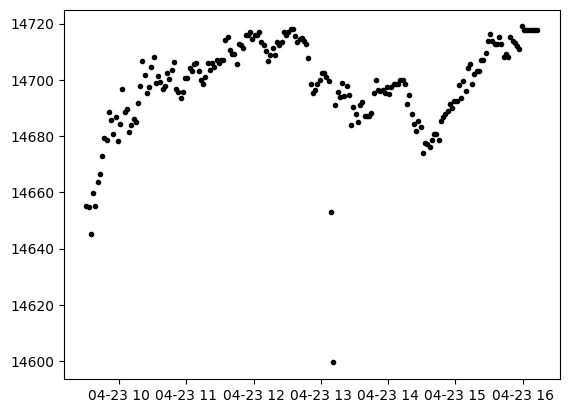

In [441]:
data = flash_crash_dji['open'].values.reshape(-1,1)[1::2]
dates = flash_crash_dji['date'].values.reshape(-1,1)[1::2]

arr1inds = dates[:,0].argsort()
data = data
dates = dates

plt.plot(dates,data,'k.')

In [443]:
class MyScaler:
    def __init__(self):
        pass

    def fit(self, x):
        self.mu  = np.median(x)
        self.std = np.std(x)

    def transform(self, x):
        return (x-self.mu)/self.std

    def inverse_transform_mean(self, x):
        '''To transform mean'''
        return x*self.std + self.mu

    def inverse_transform_std(self, x):
        '''To transform standard deviation'''
        return x*self.std

In [444]:
class RobustScaler2(RobustScaler):

    def inverse_transform_mean(self, x):
        '''To transform mean'''
        return x*self.scale_ + self.center_

    def inverse_transform_std(self, x):
        '''To transform standard deviation'''
        return x*self.scale_

NameError: name 'RobustScaler' is not defined

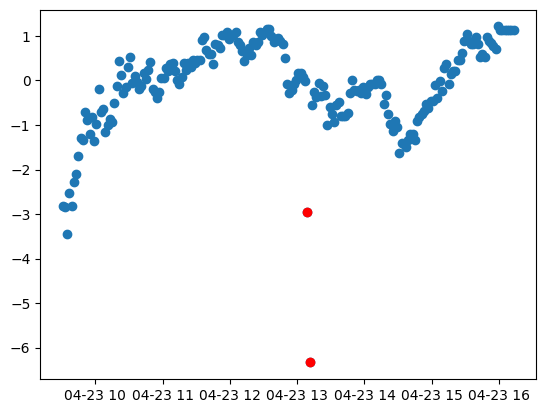

In [445]:
dates_float = dates.astype(np.float64)
x_scaler = StandardScaler()
y_scaler = MyScaler()
dates_normalised = x_scaler.fit_transform(dates_float)
y_scaler.fit(data)
data_normalised = y_scaler.transform(data)
plt.scatter(dates,data_normalised)
plt.scatter(dates[[109,110]],data_normalised[[109,110]], color = 'r')

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 181.02140463324358
        x: [-2.928e+00  7.505e-02 -1.675e+00]
      nit: 18
      jac: [-9.016e-06 -9.018e-06 -6.358e-07]
     nfev: 20
     njev: 20
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,0.731375
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,0.0521246
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.171707


ValueError: 2 is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

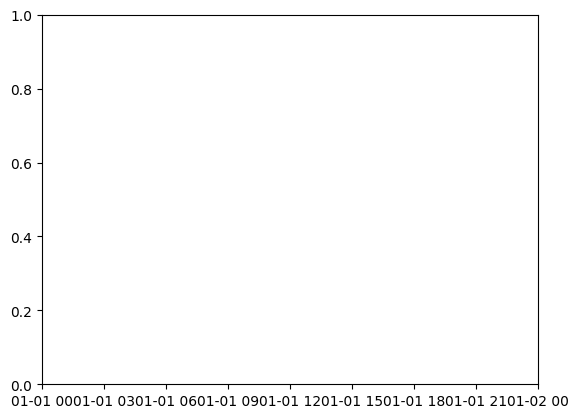

In [448]:
standard_gp = gpflow.models.GPR(
    (dates_normalised, data_normalised),
    kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01,variance = 0.01),
    noise_variance = 0.01
)

opt = gpflow.optimizers.Scipy()
opt_options = dict()
res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables, options=opt_options)
print(res)
gpflow.utilities.print_summary(standard_gp, "notebook")

f_mean, f_var = standard_gp.predict_f(dates_normalised, full_cov=False)

f_std = np.sqrt(f_var)

f_mean, f_std = y_scaler.inverse_transform_mean(f_mean), y_scaler.inverse_transform_std(f_std)


plt.plot(dates[:,0], f_mean, c=2, lw=4, label= 'Standard GP Prediction')
#plt.plot(dates, standard_gp.mean_function(dates_normalised))

plt.plot(dates, data, 'k.', ms=7, alpha=0.5, label = 'Observations')
plt.xlim(dates[0], dates[-1])
plt.legend(ncol=4, frameon=True, shadow=False, loc=9, edgecolor='k')
plt.tight_layout()